Notebook pre-requisites:

In [156]:
!pip install "camelot-py[cv]"
!pip install spacy



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [157]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 25.2 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [158]:
!pip install PyMuPDF
!pip install pdfplumber


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


## 1. PDF Ingestion & Parsing
- Extract text with page/section anchors (page number, heading hierarchy).
- Preserve structure: titles, subsections, lists, tables, figures’ captions.
- For tables: parse into machine-readable frames (CSV/JSON) when possible.
- Deliverables: raw_text.jsonl (chunks with metadata), tables/*.csv.

In [ ]:
import fitz
import json
import re
from pathlib import Path
import shutil
import camelot
import pdfplumber
import pandas as pd

# =============== TOC EXTRACTION ===============
def extract_contents_section(doc):
    toc_lines = []
    toc_started = False
    current_title = ""
    suppressing = False  # True when we've seen THL but not yet seen FOOD

    toc_header_re = re.compile(r"\b(Contents|Table of Contents)\b", re.IGNORECASE)
    toc_entry_re = re.compile(r"\.{3,}\s*(\d+)$")  # dots then page number at EOL
    thl_re = re.compile(r"THL", re.IGNORECASE)
    food_re = re.compile(r"FOOD", re.IGNORECASE)

    for page in doc:
        lines = page.get_text().splitlines()
        for line in lines:
            stripped = line.strip()
            if not stripped:
                continue
            if not toc_started and toc_header_re.search(stripped):
                toc_started = True
                continue
            if not toc_started:
                continue

            # suppression logic
            if suppressing:
                m_food = food_re.search(stripped)
                if m_food:
                    stripped = stripped[m_food.end():].strip()
                    suppressing = False
                    if not stripped:
                        continue
                else:
                    continue

            m_thl = thl_re.search(stripped)
            if m_thl:
                m_food = food_re.search(stripped, m_thl.end())
                if m_food:
                    stripped = stripped[m_food.end():].strip()
                    if not stripped:
                        continue
                else:
                    stripped = stripped[:m_thl.start()].strip()
                    suppressing = True
                    if not stripped:
                        continue

            match = toc_entry_re.search(stripped)
            if match:
                full_title = (current_title + " " + stripped).strip() if current_title else stripped
                toc_lines.append(full_title)
                current_title = ""
            else:
                if current_title:
                    current_title += " " + stripped
                else:
                    current_title = stripped

        last_few = lines[-5:]
        if toc_started and all(not toc_entry_re.search(l.strip()) for l in last_few):
            break

    if current_title:
        if suppressing:
            last_thl = re.search(r"THL", current_title, re.IGNORECASE)
            cleaned_title = current_title[:last_thl.start()].strip() if last_thl else ""
        else:
            cleaned_title = current_title.strip()
        if cleaned_title:
            toc_lines.append(cleaned_title)

    return "\n".join(toc_lines)

# =============== PARSE CONTENTS TO DATAFRAME ===============
def parse_contents_to_df(contents_text):
    lines = [l.strip() for l in contents_text.split("\n") if re.search(r"\d+\s*$", l)]
    rows = []
    for line in lines:
        match = re.match(r"(.+?)\s+(\d+)$", line)
        if match:
            title, page = match.groups()
            title = re.sub(r"\.{2,}", "", title).strip()
            rows.append([title, int(page)])
    df = pd.DataFrame(rows, columns=["title", "page"])
    df = merge_split_rows(df)
    return df

def merge_split_rows(df):
    return df

def normalize_text(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip().lower()

# =============== TABLE EXTRACTION USING CAMELT/PLUMBER ===============
def extract_tables(pdf_path, output_dir):
    output_dir = Path(output_dir)
    tables_dir = output_dir / "tables"
    if tables_dir.exists():
        shutil.rmtree(tables_dir)
    tables_dir.mkdir(exist_ok=True)

    all_tables = []
    doc = fitz.open(pdf_path)

    for page_num in range(len(doc)):
        page_str = str(page_num + 1)
        page_tables = []

        # Camelot STREAM
        try:
            tables_stream = camelot.read_pdf(pdf_path, pages=page_str, flavor='stream', edge_tol=50, row_tol=10, strip_text='\n')
            page_tables += [t.df for t in tables_stream if not t.df.empty]
        except Exception:
            pass

        # Camelot LATTICE
        if not page_tables:
            try:
                tables_lattice = camelot.read_pdf(pdf_path, pages=page_str, flavor='lattice', line_scale=40, shift_text=['l','t'])
                page_tables += [t.df for t in tables_lattice if not t.df.empty]
            except Exception:
                pass

        # pdfplumber fallback
        if not page_tables:
            with pdfplumber.open(pdf_path) as pdf:
                page = pdf.pages[page_num]
                plumber_tables = page.extract_tables()
                for pt in plumber_tables:
                    df = pd.DataFrame(pt)
                    page_tables.append(df)

        # Save tables
        for i, df in enumerate(page_tables):
            df = df.fillna("").astype(str).apply(lambda col: col.map(lambda x: re.sub(r"\n", " ", x).strip()))
            df = merge_split_rows(df)
            table_file = tables_dir / f"table_page{page_num+1}_{i+1}.csv"
            df.to_csv(table_file, index=False)
            all_tables.append({
                "table_number": i + 1,
                "page": page_num + 1,
                "file": str(table_file),
                "rows": df.shape[0],
                "columns": df.shape[1]
            })

    print(f"✓ Extracted {len(all_tables)} tables total to '{tables_dir}'")
    return all_tables

# =============== MAIN EXTRACTION FUNCTION ===============
def extract_pdf_with_structure(pdf_path, output_dir="data"):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    doc = fitz.open(pdf_path)
    chunks = []

    # --- Extract TOC and parse ---
    contents_text = extract_contents_section(doc)
    toc_df = parse_contents_to_df(contents_text)
    toc_df = toc_df.sort_values(by="page").reset_index(drop=True)

    toc_index = 0
    current_section = ""

    for page_num in range(len(doc)):
        page = doc[page_num]
        lines = page.get_text().splitlines()

        new_sections = []
        while toc_index < len(toc_df) and toc_df.loc[toc_index, "page"] <= page_num + 1:
            new_sections.append(toc_df.loc[toc_index, "title"])
            toc_index += 1

        pending_sections = new_sections.copy()
        buffer = []
        line_idx = 0

        while line_idx < len(lines):
            matched_section = None
            matched_lines_count = 0
            for section_title in pending_sections:
                for lookahead in range(1, min(5, len(lines) - line_idx + 1)):
                    candidate_text = " ".join(lines[line_idx:line_idx+lookahead])
                    if normalize_text(candidate_text).startswith(normalize_text(section_title)):
                        matched_section = section_title
                        matched_lines_count = lookahead
                        break
                if matched_section:
                    break

            if matched_section:
                if current_section and buffer:
                    text_chunk = " ".join(buffer).strip()
                    if text_chunk:
                        chunks.append({"page": page_num+1, "section": current_section, "text": text_chunk})
                current_section = matched_section
                buffer = []
                pending_sections.remove(matched_section)
                line_idx += matched_lines_count
                continue
            else:
                if current_section:
                    buffer.append(lines[line_idx].strip())
                line_idx += 1

        if current_section and buffer:
            text_chunk = " ".join(buffer).strip()
            if text_chunk:
                chunks.append({"page": page_num+1, "section": current_section, "text": text_chunk})

        if pending_sections:
            for missing_section in pending_sections:
                print(f"[WARNING] Section '{missing_section}' expected on page {page_num+1} but not found.")
                if buffer:
                    text_chunk = " ".join(buffer).strip()
                    if text_chunk:
                        chunks.append({"page": page_num+1, "section": missing_section, "text": text_chunk})
                        buffer = []

    # Save text
    output_file = output_dir / "raw_text.jsonl"
    with open(output_file, "w", encoding="utf-8") as f:
        for chunk in chunks:
            f.write(json.dumps(chunk, ensure_ascii=False) + "\n")

    print(f"✓ Extracted {len(chunks)} text chunks")
    print(f"✓ Clean text saved to {output_file}")

    # --- Extract tables using Camelot/pdfplumber ---
    tables_info = extract_tables(pdf_path, output_dir)

    return chunks, toc_df, tables_info


In [160]:
pdf_path = "data/sustainable-health-from-food_web.pdf"
chunks, toc_df, tables = extract_pdf_with_structure(pdf_path)

[WARNING] Section 'Appendix 8. Recommended intakes of fat, carbohydrates and protein for adults and children over 2 years (without alcohol and with fibre taken into account)' expected on page 102 but not found.
✓ Extracted 134 text chunks
✓ Clean text saved to data/raw_text.jsonl


/Users/beatricezani/Desktop/Uni/NLP/pdf_to_KnowledgeGraph_LLM/.venv/lib/python3.10/site-packages/camelot/parsers/base.py:238: UserWarning: No tables found in table area (0, 0, 498.898, 708.661)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)
/Users/beatricezani/Desktop/Uni/NLP/pdf_to_KnowledgeGraph_LLM/.venv/lib/python3.10/site-packages/camelot/parsers/base.py:238: UserWarning: No tables found in table area (63.7008, 137.1649, 437.67889999999966, 681.5164555555556)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)
/Users/beatricezani/Desktop/Uni/NLP/pdf_to_KnowledgeGraph_LLM/.venv/lib/python3.10/site-packages/camelot/parsers/base.py:238: UserWarning: No tables found in table area (92.0472, 302.90479999999997, 462.89330000000035, 684.5557947368421)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)
/Users/beatricezani/Desktop/Uni/NLP/pdf_to_KnowledgeGraph_LLM/.venv/lib/python3.10/site-packages/camelot/parsers/base.

✓ Extracted 137 tables total to 'data/tables'


/Users/beatricezani/Desktop/Uni/NLP/pdf_to_KnowledgeGraph_LLM/.venv/lib/python3.10/site-packages/camelot/parsers/base.py:238: UserWarning: No tables found in table area (53.76729999999999, 246.3673, 449.4282999999997, 630.1827161904762)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)


## 3) NER & Keyphrase Extraction

In [161]:
!pip install spacy
!pip install transformers
!pip install keybert
!pip install scispacy
!pip install fuzzywuzzy python-Levenshtein
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Using cached scispacy-0.6.2-py3-none-any.whl.metadata (20 kB)
  Using cached conllu-6.0.0-py3-none-any.whl.metadata (21 kB)
  Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl.metadata (61 kB)
  Using cached nmslib-metabrainz-2.1.3.tar.gz (196 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pysbd-0.3.4-py3-none-any.whl.metadata (6.1 kB)
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requ

In [162]:
import json
import pandas as pd
import spacy
from keybert import KeyBERT
import yaml

# load Text Chunks
with open('data/raw_text.jsonl', 'r') as f:
    text_chunks = [json.loads(line) for line in f]
df_chunks = pd.DataFrame(text_chunks)
print(f"Loaded {len(df_chunks)} text chunks.")

# Load Ontology
with open('data/ontology.yaml', 'r') as f:
    ontology = yaml.safe_load(f)
entity_classes = list(ontology.get('classes', {}).keys())
print(f"Ontology classes: {entity_classes}")

Loaded 134 text chunks.
Ontology classes: ['ingredient', 'nutrient', 'technique', 'dietaryGuideline', 'healthOutcome', 'environmentImpact']


In [163]:
!pip install yake


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


## 4. Relation Extraction & Triple Building
- Use rule-based patterns and/or relation extraction models to detect relations (e.g., Ingredient X contains
Nutrient Y, Technique Z requires Temperature T).
- Convert to triples (RDF or property graph). Include provenance (page, line span).
- Deduplicate and validate (schema consistency).
- Deliverables: triples.ttl (RDF) or graph.json (property graph).

In [ ]:
import json
from rdflib import Graph, Namespace, URIRef, Literal
from collections import defaultdict

# Load ontology namespace
EX = Namespace("http://example.org/food#")

# Initialize RDF graph
g = Graph()
g.bind("ex", EX)

# Load entities
entities = []
with open("data/entities_lowercased.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        entities.append(json.loads(line))

# Flatten mentions: one record per page + entity
flat_entities = []
for e in entities:
    for mention in e.get("mentions", []):
        flat_entities.append({
            "id": e["id"],
            "entity": e["label"],
            "ontology_type": e["type"],
            "page": mention["page"],
            "surface": mention["surface"],
            "context": mention.get("context", "")
        })

# Simple canonicalization: lowercasing and deduplicating by page & type
canonical_entities = {}
for e in flat_entities:
    key = (e["page"], e["ontology_type"], e["entity"].lower())
    canonical_entities[key] = e

# Group entities by page
entities_by_page = defaultdict(list)
for (page, otype, _), e in canonical_entities.items():
    entities_by_page[page].append(e)

# Relation extraction rules (simple co-occurrence + keyword heuristics)
def extract_relations(page_entities):
    triples = []
    for e1 in page_entities:
        for e2 in page_entities:
            if e1 == e2:
                continue
            # Ingredient → Nutrient
            if e1["ontology_type"] == "ingredient" and e2["ontology_type"] == "nutrient":
                triples.append((e1["entity"], "hasNutrient", e2["entity"]))

            # Ingredient → Technique
            elif e1["ontology_type"] == "ingredient" and e2["ontology_type"] == "technique":
                triples.append((e1["entity"], "usesTechnique", e2["entity"]))

            # Ingredient → DietaryGuideline
            elif e1["ontology_type"] == "ingredient" and e2["ontology_type"] == "dietaryGuideline":
                triples.append((e1["entity"], "hasGuideline", e2["entity"]))

            # Ingredient → HealthOutcome
            elif e1["ontology_type"] == "ingredient" and e2["ontology_type"] == "healthOutcome":
                triples.append((e1["entity"], "associatedWithOutcome", e2["entity"]))

            # Ingredient → EnvironmentImpact
            elif e1["ontology_type"] == "ingredient" and e2["ontology_type"] == "environmentImpact":
                triples.append((e1["entity"], "hasEnvironmentalImpact", e2["entity"]))

            # Nutrient → HealthOutcome
            elif e1["ontology_type"] == "nutrient" and e2["ontology_type"] == "healthOutcome":
                triples.append((e1["entity"], "affectsRiskOf", e2["entity"]))

            # DietaryGuideline → Technique
            elif e1["ontology_type"] == "dietaryGuideline" and e2["ontology_type"] == "technique":
                triples.append((e1["entity"], "recommendsTechnique", e2["entity"]))

            # DietaryGuideline → HealthOutcome
            elif e1["ontology_type"] == "dietaryGuideline" and e2["ontology_type"] == "healthOutcome":
                triples.append((e1["entity"], "aimsToImprove", e2["entity"]))

            # DietaryGuideline → EnvironmentImpact
            elif e1["ontology_type"] == "dietaryGuideline" and e2["ontology_type"] == "environmentImpact":
                triples.append((e1["entity"], "guidelineTargetsImpact", e2["entity"]))

            # Technique → EnvironmentImpact
            elif e1["ontology_type"] == "technique" and e2["ontology_type"] == "environmentImpact":
                triples.append((e1["entity"], "affectsImpactCategory", e2["entity"]))
    return triples

# Build RDF triples
for page, page_entities in entities_by_page.items():
    relations = extract_relations(page_entities)
    for subj, pred, obj in relations:
        subj_uri = EX[subj.replace(" ", "_")]
        obj_uri = EX[obj.replace(" ", "_")]
        g.add((subj_uri, EX[pred], obj_uri))
        # store page info as triple-level metadata (comment)
        g.add((subj_uri, RDFS.comment, Literal(f"Found on page {page}")))


# Serialize graph to Turtle
g.serialize("data/triples1.ttl", format="turtle")
print("RDF triples saved to triples.ttl")


## point 5

In [165]:
!pip install rdflib pandas


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [166]:
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS
import pandas as pd

# Load your triples.ttl file
g = Graph()
g.parse("data/triples1.ttl", format="turtle")

print(f"Loaded {len(g)} triples")



Loaded 4796 triples


In [167]:
EX = Namespace("http://example.org/ex#")
g.bind("ex", EX)

In [168]:
# Example SPARQL query: Count total triples

q1 = """SELECT (COUNT(*) AS ?totalTriples) WHERE { ?s ?p ?o . }"""
for row in g.query(q1):
    print("Total Triples:", row.totalTriples)


Total Triples: 4796


In [169]:
# Example SPARQL query: List all entities and their types

q2 = """
SELECT ?entity ?nutrient
WHERE {
  ?entity ex:hasNutrient ?nutrient .
}
LIMIT 20
"""
pd.DataFrame(g.query(q2), columns=["Entity", "Nutrient"])


,Entity,Nutrient
0,http://example.org/food#alcohol,http://example.org/food#calcium
1,http://example.org/food#barley,http://example.org/food#calcium
2,http://example.org/food#berries,http://example.org/food#calcium
3,http://example.org/food#beverages,http://example.org/food#calcium
4,http://example.org/food#cereals,http://example.org/food#calcium
5,http://example.org/food#dairy,http://example.org/food#calcium
6,http://example.org/food#eggs,http://example.org/food#calcium
7,http://example.org/food#fats,http://example.org/food#calcium
8,http://example.org/food#fish,http://example.org/food#calcium
9,http://example.org/food#fruits,http://example.org/food#calcium


In [170]:
q3 = """
SELECT ?entity ?comment
WHERE {
  ?entity rdfs:comment ?comment .
}
ORDER BY ?comment
LIMIT 5
"""

results = g.query(q3)
df = pd.DataFrame(results, columns=["Entity", "Comment"])

# Optionally extract numeric page number from the comment text
df["Page"] = df["Comment"].str.extract(r"(\d+)")
df.drop(columns=["Comment"], inplace=True)
df


,Entity,Page
0,http://example.org/food#poultry,10
1,http://example.org/food#processed_meat,10
2,http://example.org/food#red_meat,10
3,http://example.org/food#alcohol,102
4,http://example.org/food#berries,102


## Point 6

In [171]:
from rdflib import Graph, Namespace, Literal
import pandas as pd, json

g = Graph()
g.parse("data/triples1.ttl", format="turtle")
EX = Namespace("http://example.org/ex#")
g.bind("ex", EX)
print(f"Loaded {len(g)} triples")


Loaded 4796 triples


In [172]:
print("Sample predicates from your TTL:")
for p in set(g.predicates()):
    print(p)


Sample predicates from your TTL:
http://example.org/food#hasGuideline
http://example.org/food#aimsToImprove
http://example.org/food#usesTechnique
http://example.org/food#affectsRiskOf
http://www.w3.org/2000/01/rdf-schema#comment
http://example.org/food#affectsImpactCategory
http://example.org/food#associatedWithOutcome
http://example.org/food#recommendsTechnique
http://example.org/food#guidelineTargetsImpact
http://example.org/food#hasNutrient
http://example.org/food#hasEnvironmentalImpact


In [ ]:
query = """
PREFIX ex: <http://example.org/food#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?s ?p ?o ?page
WHERE {
  ?s ?p ?o .
  FILTER(STRSTARTS(STR(?p), "http://example.org/food#"))

  OPTIONAL {
    ?s rdfs:comment ?comment .
    BIND(xsd:integer(REPLACE(STR(?comment), "Found on page ", "")) AS ?page)
  }
}
"""

rows = []
for s, p, o, page in g.query(query):
    rows.append({
        "subject": str(s).split("#")[-1],
        "predicate": str(p).split("#")[-1],
        "object": str(o).split("#")[-1],
        "page": str(page) if page else None
    })

facts_df = pd.DataFrame(rows)
facts_df.head()


In [ ]:

def make_paraphrases(row):
    s, p, o = row["subject"], row["predicate"], row["object"]

    templates = {
        "hasNutrient": [
            f"{s} contains {o}.",
            f"{o} is a nutrient found in {s}."
        ],
        "usesTechnique": [
            f"{s} is prepared using {o}.",
            f"The preparation of {s} involves {o}."
        ],
        "hasGuideline": [
            f"{s} follows the guideline: {o}.",
            f"The dietary guideline {o} applies to {s}."
        ],
        "recommendsTechnique": [
            f"The guideline {s} recommends {o}.",
            f"{s} suggests using the technique {o}."
        ],
        "aimsToImprove": [
            f"The guideline {s} aims to improve {o}.",
            f"{s} targets the health outcome {o}."
        ],
        "affectsRiskOf": [
            f"{s} affects the risk of {o}.",
            f"Consuming {s} is associated with risk of {o}."
        ],
        "associatedWithOutcome": [
            f"{s} is associated with the health outcome {o}.",
            f"{s} has a relationship with {o}."
        ],
        "hasEnvironmentalImpact": [
            f"{s} has an environmental impact: {o}.",
            f"{s} contributes to {o} impact."
        ],
        "guidelineTargetsImpact": [
            f"The guideline {s} targets environmental impact {o}.",
            f"{s} aims to reduce or manage {o}."
        ],
        "affectsImpactCategory": [
            f"{s} affects the environmental impact category {o}.",
            f"The technique {s} tends to influence {o}."
        ],
    }

    # Fallback for predicates not listed
    result = templates.get(p, [f"{s} {p} {o}."])
    return result if isinstance(result, list) else [str(result)]


# Optional: print first few paraphrases for inspection
for i, row in facts_df.head(3).iterrows():
    print(make_paraphrases(row))


# Apply the paraphrase function
facts_df["paraphrases"] = facts_df.apply(lambda row: make_paraphrases(row), axis=1).astype(object)

# Save facts with paraphrases to JSONL
facts_jsonl_path = "data/facts.jsonl"
with open(facts_jsonl_path, "w", encoding="utf-8") as f:
    for _, row in facts_df.iterrows():
        record = {
            "subject": row["subject"],
            "predicate": row["predicate"],
            "object": row["object"],
            "page": row["page"],
            "paraphrases": row["paraphrases"]
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Facts with paraphrases saved to {facts_jsonl_path}")


## Point 7

In [175]:
facts = []
with open("data/facts.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        facts.append(json.loads(line))

facts_df = pd.DataFrame(facts)

In [ ]:
# return top-k facts supporting a query
def get_grounding(subject=None, predicate=None, object_=None, top_k=3):
    df = facts_df.copy()
    if subject: df = df[df['subject'].str.contains(subject, case=False)]
    if predicate: df = df[df['predicate'].str.contains(predicate, case=False)]
    if object_: df = df[df['object'].str.contains(object_, case=False)]
    df = df.head(top_k)
    return df[['subject','predicate','object','page']].to_dict(orient='records')

In [ ]:
def generate_response(instruction_type, **kwargs):
    """
    Returns a text response and grounding facts based on instruction type.
    """
    if instruction_type == "factoid":
        # kwargs: subject, predicate
        # example: subject="Spinach", predicate="hasNutrient"
        grounding = get_grounding(subject=kwargs.get("subject"), predicate=kwargs.get("predicate"), top_k=3)
        if grounding:
            objects = [g['object'] for g in grounding]
            pages = [str(g['page']) for g in grounding if g['page']]
            answer = f"{', '.join(objects)} (Source: p.{', p.'.join(pages)})"
        else:
            answer = "No data found."
            grounding = []
        return answer, grounding

    elif instruction_type == "list":
        # kwargs: predicate, object (filter)
        grounding = get_grounding(predicate=kwargs.get("predicate"), object_=kwargs.get("object_"), top_k=5)
        if grounding:
            objects = [g['subject'] for g in grounding]
            pages = [str(g['page']) for g in grounding if g['page']]
            answer = f"{', '.join(objects)}. (Source: p.{', p.'.join(pages)})"
        else:
            answer = "No data found."
            grounding = []
        return answer, grounding

    # reasoning/constraint can be implemented similarly by filtering on multiple columns


In [ ]:
dataset = []

# Example Factoid QA
instruction = "What nutrient is high in eggs?"
output, grounding = generate_response("factoid", subject="eggs", predicate="hasNutrient")
dataset.append({
    "instruction": instruction,
    "input": "",
    "output": output,
    "grounding": grounding
})

# Example List / Compare
instruction2 = "List two ingredients rich in fiber."
output2, grounding2 = generate_response("list", predicate="hasNutrient", object_="fiber")
dataset.append({
    "instruction": instruction2,
    "input": "",
    "output": output2,
    "grounding": grounding2
})

# Save to JSONL
with open("data/instruction_response_dataset.jsonl", "w", encoding="utf-8") as f:
    for item in dataset:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"Generated {len(dataset)} instruction-response pairs")


In [10]:
def predicate_to_verb(predicate):
    mapping = {
        "hasNutrient": "contains",
        "usesTechnique": "is prepared using",
        "hasGuideline": "follows the guideline",
        "recommendsTechnique": "recommends",
        "aimsToImprove": "aims to improve",
        "affectsRiskOf": "affects the risk of",
        "associatedWithOutcome": "is associated with",
        "hasEnvironmentalImpact": "has an environmental impact",
        "guidelineTargetsImpact": "targets environmental impact",
        "affectsImpactCategory": "affects the environmental impact category"
    }
    return mapping.get(predicate, predicate)

In [13]:
# define templates for different types of questions
TEMPLATES = {
    "hasNutrient": {
        "factoid": [
            "What nutrient is found in {s}?",
            "Which nutrient does {s} provide?",
            "What is the main nutrient in {s}?",
            "What does {s} contain that supports health?",
            "{s} is rich in which nutrient?"
        ],
        "list": [
            "List foods rich in {o}.",
            "Which ingredients are good sources of {o}?",
            "Give examples of foods containing {o}.",
            "Name three foods that are high in {o}."  # usando "three" non è un constraint?
        ],
        "constraint": [
            "Give two ingredients that contain {o}.", 
            "Find vegan foods rich in {o}.",
            "List foods with high {o} content under 200 kcal per 100g." # come fa a sapere il contenuto calorico? Non abbiamo quantity come class
        ]
    },
    "associatedWithOutcome": {
        "factoid": [
            "What health outcome is {s} associated with?",
            "How does consuming {s} affect health?",
            "{s} is linked to which health condition?",
            "What condition may be influenced by {s}?"
        ],
        "list": [
            "List foods associated with reduced risk of {o}.",
            "Which foods promote {o}?",
            "Name foods linked to {o}."
        ]
    },
    "affectsRiskOf": {
        "factoid": [
            "What health outcome does {s} influence?",
            "Which disease risk is affected by {s}?",
            "How does {s} affect the risk of {o}?",
            "What role does {s} play in preventing {o}?"
        ]
    },
    "usesTechnique": {
        "factoid": [
            "What technique is used to prepare {s}?",
            "How is {s} typically cooked or processed?",
            "What preparation method applies to {s}?"
        ]
    },
    "affectsImpactCategory": {
        "factoid": [
            "What environmental impact is influenced by {s}?",
            "Which sustainability impact is affected by {s}?",
            "How does {s} affect environmental footprint?"
        ],
        "reasoning": [
            "If a recipe uses {s}, what environmental impact may increase?",
            "When {s} is used, which environmental category might be affected?"
        ]
    },
    "hasGuideline": {
        "factoid": [
            "What dietary guideline applies to {s}?",
            "What recommendation is given regarding {s}?",
            "What official advice mentions {s}?"
        ]
    },
    "aimsToImprove": {
        "factoid": [
            "What health outcome does {s} aim to improve?",
            "What benefit does {s} target?",
            "Which condition is addressed by {s}?"
        ]
    },
    "guidelineTargetsImpact": {
        "factoid": [
            "What environmental impact does {s} aim to reduce?",
            "Which sustainability metric is targeted by {s}?"
        ]
    }
}

In [ ]:
# Generate diverse QA pairs from facts

import json
import random
import pandas as pd
from pathlib import Path

# establish paths
facts_path = Path("data/facts.jsonl")
output_dir = Path("data/train/test/val")
output_dir.mkdir(parents=True, exist_ok=True)

# laad facts
facts = []
with open(facts_path, "r", encoding="utf-8") as f:
    for line in f:
        facts.append(json.loads(line))
facts_df = pd.DataFrame(facts)

print(f"Loaded {len(facts_df)} facts from {facts_path}")


def get_page_ref(pages):
    if not pages:
        return ""
    pages = [str(p) for p in pages if p]
    return f"(Source: p.{', p.'.join(pages)})" if pages else ""

def get_grounding(subset):
    grounding = []
    for _, row in subset.iterrows():
        grounding.append({
            "s": row["subject"],
            "p": row["predicate"],
            "o": row["object"],
            "page": row["page"]
        })
    return grounding

def format_output_list(items, pages):
    if not items:
        return ""
    
    # Number the items: 1) item1 2) item2 ...
    items_str = " ".join([f"{i+1}) {itm}" for i, itm in enumerate(items)])
    
    # Format page references
    page_ref = get_page_ref(pages)
    if page_ref:
        return f"{items_str}. {page_ref}"
    else:
        return f"{items_str}."

# generate functions of different type
def generate_factoid_qa(fact):
    # TYPE 1: Factoid-style questions
    s, p, o, page = fact["subject"], fact["predicate"], fact["object"], fact["page"]

    templates = TEMPLATES.get(p, {}).get("factoid", [])
    if not templates:
        instruction = f"What is the relationship between {s.replace('_', ' ')} and {o.replace('_', ' ')}?"
        output = f"{s.replace('_', ' ')} {predicate_to_verb(p)} {o.replace('_', ' ')}. {get_page_ref([page])}"
    else:
        instruction = random.choice(templates).format(s=s.replace("_", " "), o=o.replace("_", " "))
        output = f"{s.replace('_', ' ')} {predicate_to_verb(p)} {o.replace('_', ' ')}. {get_page_ref([page])}"

    grounding = [fact.to_dict()]
    return {"instruction": instruction.strip(), "input": "", "output": output.strip(), "grounding": grounding}


def generate_list_compare(df):
    # TYPE 2: List/Compare-style questions
    nutrient_rows = df[df["predicate"] == "hasNutrient"]
    if len(nutrient_rows) < 1:
        return None

    nutrient = random.choice(nutrient_rows["object"].unique().tolist())
    subset_df = nutrient_rows[nutrient_rows["object"] == nutrient]
    sample_size = min(4, len(subset_df))
    if sample_size == 0:
        return None

    subset = subset_df.sample(sample_size)
    ingredients = [s.replace('_', ' ') for s in subset["subject"].tolist()]
    pages = [int(p) for p in subset["page"].tolist() if p]

    templates = TEMPLATES["hasNutrient"]["list"]
    instruction = random.choice(templates).format(o=nutrient.replace("_", " "))
    output = format_output_list(ingredients, pages)
    grounding = get_grounding(subset)
    return {"instruction": instruction.strip(), "input": "", "output": output.strip(), "grounding": grounding}



def generate_reasoning(df):
    # TYPE 3: Reasoning-style questions
    tech_rows = df[df["predicate"] == "affectsImpactCategory"]
    if len(tech_rows) == 0:
        return None

    row = tech_rows.sample(1).iloc[0]
    s, o, page = row["subject"], row["object"], row["page"]
    templates = TEMPLATES["affectsImpactCategory"]["reasoning"]
    instruction = random.choice(templates).format(s=s.replace("_", " "), o=o.replace("_", " "))
    output = f"{s.replace('_', ' ')} affects {o.replace('_', ' ')} impact. {get_page_ref([page])}"
    grounding = [row.to_dict()]
    return {"instruction": instruction.strip(), "input": "", "output": output.strip(), "grounding": grounding}


def generate_constraint_query(df):
    # TYPE 4: Constraint-style questions
    nutrient_rows = df[df["predicate"] == "hasNutrient"]
    if len(nutrient_rows) == 0:
        return None

    nutrient = random.choice(nutrient_rows["object"].unique().tolist())
    subset_df = nutrient_rows[nutrient_rows["object"] == nutrient]
    
    sample_size = min(3, len(subset_df))
    if sample_size == 0:
        return None  # nothing to sample

    subset = subset_df.sample(sample_size)
    ingredients = [s.replace('_', ' ') for s in subset["subject"].tolist()]
    pages = [int(p) for p in subset["page"].tolist() if p]

    templates = TEMPLATES["hasNutrient"]["constraint"]
    instruction = random.choice(templates).format(o=nutrient.replace("_", " "))
    output = format_output_list(ingredients, pages)
    grounding = get_grounding(subset)
    return {"instruction": instruction.strip(), "input": "", "output": output.strip(), "grounding": grounding}



# create the dataset
dataset = []

# one QA per fact
for _, fact in facts_df.iterrows():
    dataset.append(generate_factoid_qa(fact))

# extra random examples
for _ in range(40):
    q = generate_list_compare(facts_df)
    if q: dataset.append(q)

for _ in range(20):
    q = generate_reasoning(facts_df)
    if q: dataset.append(q)

for _ in range(20):
    q = generate_constraint_query(facts_df)
    if q: dataset.append(q)

dataset = [d for d in dataset if d]
print(f"Generated {len(dataset)} instruction–response pairs.")


# print preview of dataset
for i, item in enumerate(dataset[:3]):
    print(f"Example {i+1}:")
    print("Instruction:", item["instruction"])
    print("Output:", item["output"])
    print("Grounding:", item["grounding"])
    print()

# split in train, test and validation
# after shuffling 80% train, 10% val, 10% test
random.shuffle(dataset)
n = len(dataset)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

splits = {
    "train": dataset[:train_end],
    "val": dataset[train_end:val_end],
    "test": dataset[val_end:]
}

for split_name, data in splits.items():
    out_path = output_dir / f"{split_name}_instructions.jsonl"
    with open(out_path, "w", encoding="utf-8") as f:
        for record in data:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
    print(f"Saved {len(data)} {split_name} examples → {out_path}")


## Point 8. Baselines: RAG over KG vs. Zero-Shot LLM

- RAG-KG: Retrieve from KG (SPARQL/Cypher) + chunk text; feed to an LLM to generate answers with
citations.
- Zero-shot LLM: Prompt a non-fine-tuned model using only the user instruction (no KG).
- Record answers and metadata (latency, context length).

In [1]:
import json
import time
from pathlib import Path
import pandas as pd

# Load facts
facts = []
with open("data/facts.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        facts.append(json.loads(line))

facts_df = pd.DataFrame(facts)
print(f"Loaded {len(facts_df)} facts from KG")

# Load raw text for context retrieval
raw_texts = []
if Path("data/raw_text.jsonl").exists():
    with open("data/raw_text.jsonl", "r", encoding="utf-8") as f:
        for line in f:
            raw_texts.append(json.loads(line))
    raw_text_df = pd.DataFrame(raw_texts)
    print(f"Loaded {len(raw_text_df)} text chunks")

Loaded 17382 facts from KG
Loaded 134 text chunks


In [29]:
print(facts_df.head())

          subject     predicate               object page  \
0  processed_meat  hasGuideline  increase_vegetables   10   
1  processed_meat  hasGuideline  increase_vegetables   19   
2  processed_meat  hasGuideline  increase_vegetables   20   
3  processed_meat  hasGuideline  increase_vegetables   21   
4  processed_meat  hasGuideline  increase_vegetables   24   

                                         paraphrases  
0  [processed_meat follows the guideline: increas...  
1  [processed_meat follows the guideline: increas...  
2  [processed_meat follows the guideline: increas...  
3  [processed_meat follows the guideline: increas...  
4  [processed_meat follows the guideline: increas...  


In [ ]:
term_conversion = {
        "nutrient" : ["hasNutrient"],
        "contain" : ["hasNutrient"],
        "use" : ["usesTechnique", "hasNutrient"],
        "rich" : ["hasNutrient"],
        "find" : ["hasNutrient"],
        "ingredient" : ["hasNutrient"],
        "follow" : ["usesTechnique", "hasGuideline"],
        "affect" : ["hasEnvironmentalImpact", "affectsRiskOf", "guidelineTargetsImpact", "affectsImpactCategory"],
        "risk" : ["affectRiskOf"],
        "associate" : ["associatedWithOutcome", "hasNutrient", "usesTechnique"],
        "outcome" : ["associatedWithOutcome"],
        "recommend" : ["recommendsTechnique"],
        "environment" : ["hasEnvironmentalImpact", "guidelineTargetsImpact", "affectsImpactCategory"],
        "impact" : ["hasEnvironmentalImpact", "affectsRiskOf", "guidelineTargetsImpact", "affectsImpactCategory"],
        "prepare" : ["usesTechnique", "hasGuideline"],
        "guideline" : ["hasGuideline", "guidelineTargetsImpact"],
        "aim" : ["aimsToImprove", "hasGuideline", "guidelineTargetsImpact"],
        "improve" : ["aimsToImprove", "hasGuideline"],
        "target" : ["guidelineTargetsImpact"],
        "sustain" : ["guidelineTargetsImpact", "aimsToImprove", "hasEnvironmentalImpact", "affectsImpactCategory"],
        "benefit" : ["usesTechnique", "hasNutrient", "aimsToImprove", "hasGuideline", "hasEnvironmentalImpact", "affectsRiskOf", "guidelineTargetsImpact", "affectsImpactCategory"],
        "dietary": ["hasNutrient", "hasGuideline"],
        "advice": ["hasGuideline"],
        "preparation": ["usesTechnique", "hasNutrient"],
        "method": ["usesTechnique", "associatedWithOutcome"],
        "cook": ["usesTechnique", "associatedWithOutcome", "hasEnvironmentalImpact"],
        "process": ["usesTechnique", "hasNutrient", "associatedWithOutcome"]
    }

def predicate_to_search(query_terms):
    pred = []
    for term in query_terms:
        if term in term_conversion.keys():
            for p in term_conversion[term]:
                if p not in pred:
                    pred.append(p)
    return pred

In [ ]:
from Levenshtein import distance as levenshtein
import spacy
nlp = spacy.load("en_core_web_sm")

def fuzzy_match(df, term, predicate, edit):
    """Return rows where subject/object matches term exactly or within edit distance ≤ 2."""
    
    def check_row(row):
        subj = str(row['subject']).lower()
        obj = str(row['object']).lower()
        t   = term.lower()

        # Exact match first (fast)
        if subj == t or obj == t:
            return True
        if edit: 
            # Fuzzy match (edit distance ≤ 1)
            if levenshtein(subj, t) <= 1 or levenshtein(obj, t) <= 1:
                return True
        
        return False

    # Filter rows by predicate + fuzzy function
    filtered = df[df['predicate'] == predicate]
    return filtered[filtered.apply(check_row, axis=1)]


def retrieve_from_kg(unigram, bigram = None, top_k=5):
    """
    Retrieve relevant facts from KG based on query terms.
    Uses simple keyword matching across subject, predicate, object.
    """
    results = []
    pred = predicate_to_search(unigram)
    for p in pred:
        if bigram:
            for terms in bigram:
                # print(term)
                # Search in subject, predicate, or object
                matches = fuzzy_match(facts_df, terms, p, edit=False) ## Messo False per i bigram altrimenti dà problemi con tutte le vitamine
                if not matches.empty:
                    token_remove = terms.split("_")
                    unigram = [u for u in unigram if u not in token_remove]
                # print(f"TERM: {term}\n MATCHES:{matches}")
                results.append(matches)
        if unigram:    
            for term in unigram:
                # Search in subject, predicate, or object
                matches = fuzzy_match(facts_df, term, p)
                results.append(matches)
    # print(results)
    if results:
        combined = pd.concat(results)
        combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
        combined = combined.drop_duplicates()
        return combined

    return pd.DataFrame()


def get_text_context(fact_pages, top_k=100):
    """
    Retrieve original text chunks associated with the pages in retrieved facts.
    """
    if not raw_texts:
        return []
    
    context_chunks = []
    for page in fact_pages:
        chunks = [t for t in raw_texts if t.get('page') == page]
        context_chunks.extend(chunks)#[:top_k])
    
    return context_chunks[:top_k]


def extract_query_terms(question):
    """
    Simple extraction of key terms from question.
    In production, use NER or keyword extraction.
    """

    doc = nlp(question.lower())

    unigram = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]

    bigram = ["_".join(unigram[i:i+2]) for i in range(len(unigram)-1)]
    
    return unigram, bigram 

    # Remove common words
    #stopwords = {'what', 'which', 'how', 'is', 'are', 'the', 'a', 'an', 'in', 'on', 'at', 'to', 'for'}
    #words = question.lower().replace('?', '').split()
    #keywords = [w for w in words if w not in stopwords and len(w) > 2]
    #return keywords

print("KG retrieval functions defined")

KG retrieval functions defined


In [ ]:
question = "what do you think about saying eggs is rich in many nutrients and that can be cooked in many methods?"
qt, _ = extract_query_terms(question)
print(retrieve_from_kg(qt)["subject"].unique())
print(retrieve_from_kg(qt)["predicate"].unique())
## WORKS

C:\Users\salir\AppData\Local\Temp\ipykernel_6608\1470018535.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


['eggs']
['hasNutrient' 'usesTechnique' 'associatedWithOutcome'
 'hasEnvironmentalImpact']
['hasNutrient' 'usesTechnique' 'associatedWithOutcome'
 'hasEnvironmentalImpact']


In [ ]:
question = "what do you think about saying eggs has many nutrients?"
qt, _ = extract_query_terms(question)
print(qt)

['think', 'say', 'egg', 'nutrient']


In [27]:
question = "what do you think about saying eggs is rich in many nutrients and that can be cooked in many methods?"
qt = extract_query_terms(question)
print(predicate_to_search(qt))

['hasNutrient', 'usesTechnique', 'associatedWithOutcome', 'hasEnvironmentalImpact']


In [23]:
import os
from groq import Groq

# Initialize client
client = Groq(
    api_key=os.environ.get("GROQ_API_KEY")
)

# Send a chat request
chat_completion = client.chat.completions.create(
    model="groq/compound",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user",   "content": "Explain how photosynthesis works in simple terms."}
    ]
)

# Print the response
print(chat_completion.choices[0].message.content)


**Photosynthesis in Simple Terms**

1. **What It Is**  
   Photosynthesis is the way green plants (and some algae & bacteria) turn sunlight into food. It’s how they make the sugars they need to grow and, in the process, they produce the oxygen we breathe.

2. **The Main Ingredients**  
   - **Sunlight** – the energy source.  
   - **Carbon dioxide (CO₂)** – a gas we exhale; plants take it in through tiny holes on their leaves called *stomata*.  
   - **Water (H₂O)** – absorbed by the roots and moved up through the plant’s “veins” (xylem).

3. **Where It Happens**  
   Inside the leaf cells are tiny structures called **chloroplasts**. Chloroplasts contain a green pigment called **chlorophyll** that captures sunlight.

4. **The Two‑Step Process**  

   **A. Light‑Dependent Reactions** (needs sunlight)  
   - Chlorophyll grabs sunlight and uses that energy to split water molecules (H₂O) into oxygen (O₂), protons, and electrons.  
   - The oxygen is released into the air (that’s the O₂ we 

In [16]:
## Function made only for debug purposes and to solve prompt problems in RAG-KG

def check_context(question, model_name="gpt-3.5-turbo", top_k=5, use_chunks=False, pred_conversion=True):
    """
    check the correct generation of context
    """
    
    # 1. Extract query terms and retrieve from KG
    unigram, bigram = extract_query_terms(question)
    print(unigram, bigram)
    retrieved_facts = retrieve_from_kg(unigram, bigram)
    
    # 2. Build context from retrieved facts
    context_parts = []
    pages_cited = []
    contexts = {}

    if not retrieved_facts.empty:
        context_parts.append("Relevant Knowledge Graph Facts:")
        for idx, row in retrieved_facts.iterrows():
            key = (row['subject'], row['predicate'], row['object'])
            page = row.get('page')
            if key not in contexts:
                contexts[key] = []
            #fact_text = f"- {row['subject']} {row['predicate']} {row['object']}" 
            if pd.notna(page):
                page = int(page)
                if page not in contexts[key]:
                    contexts[key].append(page)
                    pages_cited.append(page)

        for (subj, pred, obj), pages in contexts.items():
            verb = predicate_to_verb(pred)
            if pred_conversion:
                base = f"- {subj} {verb} {obj}"
            else:
                base = f"- {subj} {pred} {obj}"
            if pages:
                page_text = ", ".join(str(p) for p in sorted(pages))
                base += f" (Page {page_text})"
            context_parts.append(base)
    
    context = "\n".join(context_parts)
    # print(f"CONTEXT:\n{context}\n")
    # 4. Build RAG prompt
    prompt = f"""Based on the following information from a food science handbook:

{context}

Please answer this question: {question}

Provide a clear answer and cite the page numbers where the information comes from."""
    
    return prompt, context

In [19]:
test_questions = [
    "What nutrients are found in eggs?",
    "List ingredients rich in fibre",
    "What is the recommended cooking temperature for poultry?", # non trova niente perchè da queste parole non trova un predicate a cui fare riferimento
    "Which foods contain vitamin C?",
    "What are the health benefits of omega-3 fatty acids?"
]

for q in test_questions:
    prompt, context = check_context(q)
    print(f"PROMPT:\n {prompt}\n")

['nutrient', 'find', 'egg'] ['nutrient_find', 'find_egg']


C:\Users\salir\AppData\Local\Temp\ipykernel_7448\530867006.py:54: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


PROMPT:
 Based on the following information from a food science handbook:

Relevant Knowledge Graph Facts:
- eggs contains calcium (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains vitamin_b12 (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains saturated_fat (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains salt (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains protein (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains vitamin_c (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains iron (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains iodine (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains selenium (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains zinc (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains vitamin_d (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)
- eggs contains fibre (Page 37, 38, 39, 43, 57, 66, 68, 71, 82, 88)

Please answer this question: What nutrients are f

In [20]:
def rag_kg_baseline(question, model_name="gpt-3.5-turbo", top_k=5, use_chunks=False, pred_conversion=True):
    """
    RAG over Knowledge Graph baseline.
    Retrieves facts from KG, builds context, and generates answer with LLM.
    
    Returns:
        - answer: Generated text
        - metadata: dict with context, facts, latency, context_length
    """
    start_time = time.time()
    
    # 1. Extract query terms and retrieve from KG
    unigram, bigram = extract_query_terms(question)
    print(unigram, bigram)
    retrieved_facts = retrieve_from_kg(unigram, bigram)
    
    # 2. Build context from retrieved facts
    context_parts = []
    pages_cited = []
    contexts = {}

    if not retrieved_facts.empty:
        context_parts.append("Relevant Knowledge Graph Facts:")
        for idx, row in retrieved_facts.iterrows():
            key = (row['subject'], row['predicate'], row['object'])
            page = row.get('page')
            if key not in contexts:
                contexts[key] = []
            #fact_text = f"- {row['subject']} {row['predicate']} {row['object']}" 
            if pd.notna(page):
                page = int(page)
                if page not in contexts[key]:
                    contexts[key].append(page)
                    pages_cited.append(page)

        for (subj, pred, obj), pages in contexts.items():
            verb = predicate_to_verb(pred)
            if pred_conversion:
                base = f"- {subj} {verb} {obj}"
            else:
                base = f"- {subj} {pred} {obj}"
            if pages:
                page_text = ", ".join(str(p) for p in sorted(pages))
                base += f" (Page {page_text})"
            context_parts.append(base)
        
        # 3. Optionally retrieve original text chunks
        if use_chunks:
            if raw_texts:                                       # PROBLEMA: capire come funziona questa cosa
                text_chunks = get_text_context(pages_cited)
                if text_chunks:
                    context_parts.append("\nRelevant Text Excerpts:")
                    for chunk in text_chunks:
                        excerpt = chunk.get('text', '')[:200]  # Limit length
                        page = chunk.get('page', 'N/A')
                        context_parts.append(f"[Page {page}] {excerpt}...")
    
    context = "\n".join(context_parts)
    # print(f"CONTEXT:\n{context}\n")
    # 4. Build RAG prompt
    prompt = f"""Based on the following information from a food science handbook:

{context}

Please answer this question: {question}

Provide a clear answer and cite the page numbers where the information comes from."""
    
    # 5. Generate with LLM
    try:
        response = client.chat.completions.create(
            model="groq/compound",
            messages=[{"role": "user", "content": prompt}]
        )
        answer = response.choices[0].message.content
    except Exception as e:
        answer = f"Error generating response: {e}"
    
    latency = time.time() - start_time
    
    metadata = {
        "method": "RAG-KG",
        "question": question,
        "retrieved_facts": retrieved_facts.to_dict('records') if not retrieved_facts.empty else [],
        "context": context,
        "context_length": len(prompt),
        "latency_seconds": latency,
        "pages_cited": sorted(set(pages_cited))
    }
    
    return answer, metadata

print("RAG-KG baseline function defined")

RAG-KG baseline function defined


In [21]:
def zero_shot_baseline(question, model_name="gpt-3.5-turbo"):
    """
    Zero-shot LLM baseline.
    Sends question directly to LLM without any KG retrieval or grounding.
    
    Returns:
        - answer: Generated text
        - metadata: dict with latency, context_length
    """
    start_time = time.time()
    
    # Simple prompt with no additional context
    prompt = f"Answer this question: {question}"
    
    # Generate with LLM
    try:
        response = client.chat.completions.create(
            model="groq/compound",
            messages=[{"role": "user", "content": prompt}]
        )
        answer = response.choices[0].message.content
    except Exception as e:
        answer = f"Error generating response: {e}"
    
    latency = time.time() - start_time
    
    metadata = {
        "method": "Zero-Shot",
        "question": question,
        "context": None,
        "context_length": len(prompt),
        "latency_seconds": latency,
        "pages_cited": []
    }
    
    return answer, metadata

print("Zero-shot baseline function defined")

Zero-shot baseline function defined


In [24]:
question = "Lists ingredients that has salt as nutrient"
answer, try2 = rag_kg_baseline(question)
print(f"ANSWER:\n{answer}")

['list', 'ingredient', 'salt', 'nutrient'] ['list_ingredient', 'ingredient_salt', 'salt_nutrient']


C:\Users\salir\AppData\Local\Temp\ipykernel_7448\530867006.py:54: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


ANSWER:
**Ingredients that contain salt (as a nutrient) and the pages where this is documented**

- **Fish** – Pages 5, 11, 20, 21, 24, 35, 37, 38, 39, 43, 52, 54, 56, 64, 66, 68, 70, 75, 82, 83, 88, 114, 115  
- **Legumes** – Pages 5, 20, 21, 24, 33, 37, 38, 39, 43, 46, 49, 50, 54, 56, 64, 66, 70, 72, 83, 99, 102, 114  
- **Beverages** – Pages 6, 22, 24, 25, 56, 60, 61, 63, 64, 71, 84, 87, 114  
- **Oats** – Pages 44, 83  
- **Fruits** – Pages 5, 8, 9, 20, 21, 22, 24, 33, 34, 35, 36, 43, 46, 64, 66, 68, 70, 76, 84, 88, 102, 114  
- **Potatoes** – Pages 20, 35, 36, 46, 48, 66, 68, 70, 72, 82, 83, 114, 116  
- **Eggs** – Pages 37, 38, 39, 43, 57, 66, 68, 71, 82, 88  
- **Vegetables** – Pages 5, 8, 9, 20, 21, 24, 33, 34, 36, 37, 38, 43, 46, 49, 56, 64, 68, 70, 76, 83, 84, 88, 102, 114, 117  
- **Barley** – Pages 11, 44, 45, 71, 83, 116  
- **Seeds** – Pages 11, 33, 36, 39, 44, 49, 51, 56, 64, 70, 72, 83, 88, 99  
- **Oils** – Pages 5, 11, 20, 36, 58, 62, 66, 70, 72, 114  
- **Rye** – Pag

In [25]:
question = "What ingredient are found in eggs?"
answer, try2 = rag_kg_baseline(question)
print(f"ANSWER:\n{answer}")

['ingredient', 'find', 'egg'] ['ingredient_find', 'find_egg']


C:\Users\salir\AppData\Local\Temp\ipykernel_7448\530867006.py:54: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


ANSWER:
**Answer**

The food‑science handbook lists the following ingredients (nutrients) as being present in eggs:

| Ingredient (nutrient) | Page(s) where it is mentioned |
|-----------------------|--------------------------------|
| Calcium               | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Vitamin B12           | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Saturated fat         | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Salt                  | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Protein               | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Vitamin C             | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Iron                  | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Iodine                | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Selenium              | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Zinc                  | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Vitamin D             | 37, 38, 39, 43, 57, 66, 68, 71, 82, 88 |
| Fibre                 | 37,

In [ ]:
# Example test questions
test_questions = [
    "What nutrients are found in eggs?",
    "List ingredients rich in fibre",
    "What is the recommended cooking temperature for poultry?",
    "Which foods contain vitamin C?",
    "What are the health benefits of omega-3 fatty acids?"
]

# Run both baselines on test questions
baseline_results = []

for question in test_questions[:3]:  # Test first 3 questions
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)
    
    # RAG-KG baseline
    print("\n[RAG-KG Baseline]")
    rag_answer, rag_meta = rag_kg_baseline(question, top_k=5)
    print(f"ANSWER: {rag_answer}...")
    print(f"Pages cited: {rag_meta['pages_cited']}")
    print(f"Context length: {rag_meta['context_length']} chars")
    print(f"Latency: {rag_meta['latency_seconds']:.3f}s")
    
    # Zero-shot baseline
    print("\n[Zero-Shot Baseline]")
    zero_answer, zero_meta = zero_shot_baseline(question)
    print(f"ANSWER: {zero_answer}...")
    print(f"Context length: {zero_meta['context_length']} chars")
    print(f"Latency: {zero_meta['latency_seconds']:.3f}s")
    
    # Store results
    baseline_results.append({
        "question": question,
        "rag_kg": {"answer": rag_answer, "metadata": rag_meta},
        "zero_shot": {"answer": zero_answer, "metadata": zero_meta}
    })

print(f"\n\nCompleted {len(baseline_results)} baseline comparisons")


Question: What nutrients are found in eggs?

[RAG-KG Baseline]
nutrient
find
egg
CONTEXT:
Relevant Knowledge Graph Facts:
- nutrient_intake hasNutrient fat (Page 20)
- nutrient_intake hasNutrient fat (Page 32)
- nutrient_intake hasNutrient fat (Page 96)
- certain_nutrients hasNutrient vitamin (Page 96)
- nutrient_recommended_range hasNutrient free_sugar (Page 34)
- nutrient_intake_reference hasNutrient minerals (Page 31)
- nutrient_recommended hasNutrient free_sugar (Page 34)
- nutrient page 115 (Page 15)
- nutrient page 115 (Page 31)
- nutrient page 115 (Page 32)
- nutrient page 115 (Page 40)
- nutrient page 115 (Page 48)
- nutrient page 115 (Page 57)
- nutrient page 115 (Page 73)
- nutrient page 115 (Page 115)
- nutrient page 115 (Page 116)
- nutrient_recommended_range hasNutrient sugar (Page 34)
- nutrient_recommended hasNutrient sugar (Page 34)
- good_nutrient_content hasNutrient sugar (Page 70)
- recommended_nutrient hasNutrient vitamins_and_minerals (Page 40)
- yielding_nutrient

C:\Users\salir\AppData\Local\Temp\ipykernel_26316\2966172025.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


ANSWER: Error generating response: Error code: 429 - {'error': {'message': 'Rate limit reached for model `meta-llama/llama-4-scout-17b-16e-instruct` in organization `org_01k8pcmhp3f5a8vwphanfnf95f` service tier `on_demand` on tokens per minute (TPM): Limit 30000, Used 27815, Requested 18324. Please try again in 32.278s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'compound', 'code': 'rate_limit_exceeded'}}...
Pages cited: [15, 20, 31, 32, 34, 36, 40, 48, 51, 55, 57, 68, 70, 73, 95, 96, 115, 116, 117]
Context length: 67470 chars
Latency: 11.262s

[Zero-Shot Baseline]
ANSWER: **Nutrients Found in Eggs – A Complete Overview**

Eggs are one of the most nutrient‑dense foods you can eat.  A single large (≈ 68 g) egg provides a balanced mix of macronutrients, vitamins, minerals, and bio‑active compounds.  Below is a synthesis of the information gathered from several reputable sources (UK Egg Information Service, American Egg Board, USDA‑s

C:\Users\salir\AppData\Local\Temp\ipykernel_26316\2966172025.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


ANSWER: Error generating response: Error code: 429 - {'error': {'message': 'Rate limit reached for model `meta-llama/llama-4-scout-17b-16e-instruct` in organization `org_01k8pcmhp3f5a8vwphanfnf95f` service tier `on_demand` on tokens per minute (TPM): Limit 30000, Used 28101, Requested 7310. Please try again in 10.822s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'compound', 'code': 'rate_limit_exceeded'}}...
Pages cited: [8, 11, 15, 20, 21, 31, 32, 33, 36, 38, 40, 44, 45, 46, 48, 51, 55, 57, 58, 59, 64, 67, 69, 70, 72, 73, 83, 95, 96, 115, 116, 117]
Context length: 27448 chars
Latency: 13.288s

[Zero-Shot Baseline]
ANSWER: Error generating response: Error code: 429 - {'error': {'message': 'Rate limit reached for model `meta-llama/llama-4-scout-17b-16e-instruct` in organization `org_01k8pcmhp3f5a8vwphanfnf95f` service tier `on_demand` on tokens per minute (TPM): Limit 30000, Used 24612, Requested 7513. Please try again in 4.25s. Nee

C:\Users\salir\AppData\Local\Temp\ipykernel_26316\2966172025.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


ANSWER: Error generating response: Error code: 429 - {'error': {'message': 'Rate limit reached for model `meta-llama/llama-4-scout-17b-16e-instruct` in organization `org_01k8pcmhp3f5a8vwphanfnf95f` service tier `on_demand` on tokens per minute (TPM): Limit 30000, Used 24445, Requested 5810. Please try again in 510ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'compound', 'code': 'rate_limit_exceeded'}}...
Pages cited: [31, 33, 34, 36, 38, 40, 46, 55, 69, 70, 83]
Context length: 25855 chars
Latency: 11.964s

[Zero-Shot Baseline]
ANSWER: **Answer:**  
The recommended safe minimum internal cooking temperature for all poultry (chicken, turkey, duck, goose, ground poultry, giblets, etc.) is **165 °F (74 °C)**.

---

### How we arrived at this answer  

1. **Search for authoritative guidance** – A web search for “recommended cooking temperature for poultry” returned several reliable sources, including government and food‑safety organiza

In [36]:
# Save detailed results to JSON
baseline_output_path = Path("data/baseline_results.json")
with open(baseline_output_path, "w", encoding="utf-8") as f:
    json.dump(baseline_results, f, ensure_ascii=False, indent=2, default=str)

print(f"Saved baseline results to {baseline_output_path}")

# Create summary comparison table
summary_data = []
for result in baseline_results:
    summary_data.append({
        "Question": result["question"][:50] + "...",
        "RAG-KG Context Length": result["rag_kg"]["metadata"]["context_length"],
        "RAG-KG Latency (s)": f"{result['rag_kg']['metadata']['latency_seconds']:.3f}",
        "RAG-KG Citations": len(result["rag_kg"]["metadata"]["pages_cited"]),
        "Zero-Shot Context Length": result["zero_shot"]["metadata"]["context_length"],
        "Zero-Shot Latency (s)": f"{result['zero_shot']['metadata']['latency_seconds']:.3f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n=== Baseline Comparison Summary ===")
print(summary_df.to_string(index=False))

Saved baseline results to data\baseline_results.json

=== Baseline Comparison Summary ===
                                             Question  RAG-KG Context Length RAG-KG Latency (s)  RAG-KG Citations  Zero-Shot Context Length Zero-Shot Latency (s)
                 What nutrients are found in eggs?...                  67470             11.262                19                        55                13.552
                    List ingredients rich in fiber...                  27448             13.288                32                        52                34.265
What is the recommended cooking temperature for po...                  25855             11.964                11                        78                 6.978


**Key Metrics to Track:**
- **Context Length**: RAG-KG uses more tokens (costs more)
- **Latency**: RAG-KG has retrieval overhead
- **Citations**: RAG-KG provides page numbers, Zero-shot cannot
- **Factuality**: Compare against ground truth (Point 10)
- **Hallucination Rate**: Check if facts are supported by KG (Point 11)

## 9. Fine-Tuning Setup

- Choose model and method (e.g., Mistral-7B + LoRA or LLaMA-2-7B + adapters).
- Train on the instruction dataset. Log training/validation loss; track early stopping.
- Keep prompt template consistent (system guardrails: “Only answer using facts from the provided corpus;
include sources.”).

### Model Selection: Mistral-7B + LoRA vs LLaMA-2-7B + Adapters

**Comparison:**

| Criterion | Mistral-7B + LoRA | LLaMA-2-7B + Adapters |
|-----------|-------------------|----------------------|
| **Performance** | Better instruction following, newer architecture | Stable, widely tested |
| **Memory Efficiency** | ~7GB VRAM with 4-bit | ~7GB VRAM with 4-bit |
| **Training Speed** | Faster (optimized attention) | Slightly slower |
| **Community Support** | Growing, newer | Extensive documentation |
| **License** | Apache 2.0 (commercial use ✓) | Custom (restrictions) |
| **Context Length** | 8k tokens (better for RAG) | 4k tokens |
| **Fine-tuning Ease** | Excellent with LoRA | Excellent with PEFT adapters |

**Recommendation: Mistral-7B + LoRA** ✅
- Better instruction following out-of-the-box
- Longer context window (8k) helps with RAG-KG
- More permissive license for commercial use
- Faster training with sliding window attention

### Hallucination Mitigation Strategies

Based on the analysis, here are strategies to reduce hallucinations:

**1. Prompt Engineering**
- Strengthen system prompts with explicit warnings
- Add "If you don't know, say 'I don't have enough information'"
- Request citations for every claim

**2. Post-Processing Filters**
- Implement entity verification against KG before output
- Flag or remove unsupported claims automatically
- Add confidence scores to generated answers

**3. Fine-Tuning Improvements**
- Increase training data with negative examples
- Add examples where model should refuse to answer
- Train with citation reinforcement learning

**4. Retrieval Enhancement**
- Improve KG retrieval quality and coverage
- Add more context from original documents
- Use semantic search for better fact matching

**5. Model Selection**
- Smaller models may hallucinate more
- Consider ensemble approaches
- Use models specifically trained for factuality

### Summary: Points 10 & 11 Implementation

✅ **Point 10: Evaluation (Quality, Factuality, Faithfulness)**

**Automatic Metrics Implemented:**
1. **Exact Match** - Binary match between prediction and reference
2. **F1 Score** - Token-level overlap (best for factoid QA)
3. **ROUGE-1, ROUGE-2, ROUGE-L** - N-gram overlap (for longer responses)
4. **Citation Metrics** - Precision/Recall/F1 for page citations
5. **Faithfulness Score** - % of prediction supported by KG facts

**Comparison Framework:**
- Evaluates all 3 systems: Zero-Shot, RAG-KG, Fine-Tuned
- Side-by-side comparison tables
- Visualization with bar charts
- Results saved to JSON for further analysis

---

✅ **Point 11: Hallucination Detection & Mitigation**

**Detection Methods:**
1. **Entity Extraction** - Using spaCy NER to find claimed entities
2. **KG Alignment** - Fuzzy matching entities to knowledge graph
3. **Span Marking** - Identifies character positions of unsupported claims
4. **Hallucination Rate** - % of entities not supported by KG

**Analysis Output:**
- Per-system hallucination statistics
- Answer-level hallucination flags
- Detailed unsupported entity lists
- Visualization of hallucination rates
- Example cases with explanations

**Mitigation Strategies Documented:**
- Prompt engineering improvements
- Post-processing filters
- Fine-tuning enhancements
- Retrieval quality improvements

---

**Expected Insights:**
- **Zero-Shot**: Likely highest hallucination rate (no grounding)
- **RAG-KG**: Lower hallucination, better citations
- **Fine-Tuned**: Best balance of fluency and factuality (if trained well)

**Files Generated:**
- `evaluation/evaluation_results.json` - All metrics
- `evaluation/hallucination_results.json` - Hallucination analysis
- `evaluation/plots/evaluation_comparison.png` - Metric visualizations
- `evaluation/plots/hallucination_comparison.png` - Hallucination charts

In [1]:
# ===============================
# POINT 9: FINE-TUNING WITH MISTRAL-7B + LoRA
# ===============================

# Install required packages (run once)
# !pip install transformers datasets peft accelerate bitsandbytes trl

import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset
from trl import SFTTrainer
import json
from pathlib import Path


print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\salir\Desktop\Oulu\NLP\env310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 2060


In [2]:
# ===============================
# LOAD AND PREPARE INSTRUCTION DATASET
# ===============================

# Load train, validation, test splits
train_data = load_dataset('json', data_files='data/train/test/val/train_instructions.jsonl', split='train')
val_data = load_dataset('json', data_files='data/train/test/val/val_instructions.jsonl', split='train')
test_data = load_dataset('json', data_files='data/train/test/val/test_instructions.jsonl', split='train')

print(f"Train samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")
print(f"\nSample instruction:")
print(train_data[0])

Generating train split: 3916 examples [00:00, 83319.27 examples/s]
Generating train split: 489 examples [00:00, 48876.74 examples/s]
Generating train split: 490 examples [00:00, 44565.11 examples/s]

Train samples: 3916
Validation samples: 489
Test samples: 490

Sample instruction:
{'instruction': 'What is the relationship between nutrient intake and 20?', 'input': '', 'output': 'nutrient intake page 20. (Source: p.20)', 'grounding': [{'subject': 'nutrient_intake', 'predicate': 'page', 'object': '20', 'page': '20', 'paraphrases': ['nutrient_intake is mentioned on page 20.'], 's': None, 'p': None, 'o': None}]}


In [ ]:
# ===============================
# CONFIGURE PROMPT TEMPLATE
# ===============================

def format_instruction(sample, pred_conversion=True, paraphrases=True):
    """
    Format the instruction-response pairs with system prompt for grounding.
    Consistent prompt template with guardrails.
    """
    #system_prompt = """You are a helpful assistant answering questions about food science and nutrition.
#IMPORTANT: Only provide answers based on facts from the provided knowledge base.
#Always cite your sources with page numbers when available.
#If you don't have enough information, say so rather than making up facts."""

    system_prompt = """You are a helpful assistant answering questions about food science and nutrition.
IMPORTANT: First provide answers based on facts from the provided knowledge base.
Always cite your sources with page numbers when available.
If you don't have enough information, based on your knowledge, indicate that you did not find enough information."""
    
    instruction = sample['instruction']
    input_text = sample.get('input', '')
    output = sample['output']
    if pred_conversion:
        for pred in TEMPLATES.keys():
            if pred in output:
                output = output.replace(pred,predicate_to_verb(pred))

    # Build prompt with grounding context if available
    grounding_context = ""
    if 'grounding' in sample and sample['grounding']:
        grounding_context = "\n\nKnowledge Base Facts:\n"
        for fact in sample['grounding']:#[:5]:  # Limit to top 5 facts
            #print(fact)
            if pred_conversion and not paraphrases:
                verb = predicate_to_verb(fact.get('predicate', ''))
                grounding_context += f"- {fact.get('subject', '')} {verb} {fact.get('object', '')} (Page {fact.get('page', 'N/A')})\n"
            elif paraphrases:
                for par in fact["paraphrases"]:
                    grounding_context += f"- {par}\n"
            else:
                grounding_context += f"- {fact.get('subject', '')} {fact.get('predicate', '')} {fact.get('object', '')} (Page {fact.get('page', 'N/A')})\n"
    
    # Format as conversation
    if input_text:
        user_message = f"{instruction}\n\nContext: {input_text}{grounding_context}"
    else:
        user_message = f"{instruction}{grounding_context}"
    
    # Mistral format: <s>[INST] {prompt} [/INST] {response}</s>
    formatted = f"<s>[INST] {system_prompt}\n\n{user_message} [/INST] {output}</s>"
    
    return {"text": formatted}

# Test formatting
sample = train_data[10]
formatted_sample = format_instruction(sample)
print("Formatted prompt preview:")
print(formatted_sample['text'])

Formatted prompt preview:
<s>[INST] You are a helpful assistant answering questions about food science and nutrition.
IMPORTANT: First provide answers based on facts from the provided knowledge base.
Always cite your sources with page numbers when available.
If you don't have enough information, based on your knowledge, indicating that you did not find enough information.

How is vegetables typically cooked or processed?

Knowledge Base Facts:
- vegetables is prepared using fermentation.
- The preparation of vegetables involves fermentation.
 [/INST] vegetables is prepared using fermentation. (Source: p.70)</s>


In [6]:
## CHECKING COMPATIBILITY OF FORMAT ABOVE WITH HUGGING FACE'S datasets
from datasets import load_dataset

# Load the WikiText-2 dataset
dataset_prova = load_dataset("wikitext", "wikitext-2-raw-v1")

In [7]:
print(dataset_prova["train"][3])

{'text': ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n'}


In [11]:
## SAMPLE CODE TO SEE TOKENIZATION
from transformers import AutoTokenizer

# Load Mistral's tokenizer
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.2")
tokenizer.pad_token = tokenizer.eos_token
# Preprocessing function
def preprocess_data(example):
    return tokenizer(
        example["text"],
        truncation=True,         # Ensure inputs fit within max length
        padding="max_length",    # Add padding tokens to make all inputs equal length
        max_length=512           # Mistral's max token limit
    )

# Apply preprocessing to the dataset
tokenized_dataset = dataset.map(preprocess_data, batched=True)
print(tokenized_dataset["train"][10])  # Check tokenized output

Map: 100%|██████████| 36718/36718 [00:07<00:00, 4960.67 examples/s]

{'text': ' The game \'s battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . During missions , players select each unit using a top @-@ down perspective of the battlefield map : once a character is selected , the player moves the character around the battlefield in third @-@ person . A character can only act once per @-@ turn , but characters can be granted multiple turns at the expense of other characters \' turns . Each character has a field and distance of movement limited by their Action Gauge . Up to nine characters can be assigned to a single mission . During gameplay , characters will call out if something happens to them , such as their health points ( HP ) getting low or being knocked out by enemy attacks . Each character has specific " Potentials " , skills unique to each character . They are divided into " Personal Potential " , which are innate skills that remain unaltered unless otherwise dictated by the story and can either help or impede

In [4]:
# Apply formatting to all splits
train_dataset = train_data.map(format_instruction, remove_columns=train_data.column_names)
val_dataset = val_data.map(format_instruction, remove_columns=val_data.column_names)
test_dataset = test_data.map(format_instruction, remove_columns=test_data.column_names)

print(f"Formatted datasets ready:")
print(f"Train: {len(train_dataset)} samples")
print(f"Val: {len(val_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")

Formatted datasets ready:
Train: 13969 samples
Val: 1746 samples
Test: 1747 samples


In [ ]:
print(train_dataset[0])

In [5]:
import transformers, accelerate, torch
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Torch:", torch.__version__)

Transformers: 4.57.1
Accelerate: 1.11.0
Torch: 2.7.1+cu118


In [6]:
# MISTRAL-7B WITH 4-BIT QUANTIZATION loading

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

# 4-bit quantization config for memory efficiency
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load model with quantization
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Prepare model for k-bit training
model = prepare_model_for_kbit_training(model)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Model loaded: {model_name}")
print(f"Model size: ~7B parameters")
print(f"Memory footprint: ~7GB with 4-bit quantization")

Loading checkpoint shards: 100%|██████████| 3/3 [00:33<00:00, 11.09s/it]


Model loaded: mistralai/Mistral-7B-Instruct-v0.2
Model size: ~7B parameters
Memory footprint: ~7GB with 4-bit quantization


In [7]:
# CONFIGURE LoRA (Low-Rank Adaptation) Configuration
# set before heavy allocations (you can set it in the shell too)
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128,garbage_collection_threshold:0.6"


lora_config = LoraConfig(
    r=8, #16                        # Rank of LoRA matrices (higher = more capacity)
    lora_alpha=16, #32              # Scaling factor (typically 2*r)
    target_modules=[             # Which layers to apply LoRA to
        "q_proj",
        #"k_proj",
        "v_proj",
        #"o_proj",
        #"gate_proj",
        #"up_proj",
        #"down_proj",
    ],
    lora_dropout=0.05,           # Dropout for LoRA layers
    bias="none",                 # Don't train bias parameters
    task_type="CAUSAL_LM"        # Task type
)

# Apply LoRA to model
model = get_peft_model(model, lora_config)

# Print trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
trainable_percent = 100 * trainable_params / all_params

print(f"Trainable parameters: {trainable_params:,} / {all_params:,} ({trainable_percent:.2f}%)")
print(f"Memory efficient: Only training {trainable_percent:.2f}% of parameters!")

Trainable parameters: 3,407,872 / 3,755,479,040 (0.09%)
Memory efficient: Only training 0.09% of parameters!


In [8]:
# TRAINING ARGUMENTS CONFIGURATION
if not getattr(model, "is_gradient_checkpointing", False):
    try:
        model.gradient_checkpointing_enable()
    except Exception:
        # fallback for PEFT-wrapped models
        for m in model.modules():
            if hasattr(m, "gradient_checkpointing"):
                m.gradient_checkpointing = True

output_dir = "./models/fine_tuned_model"
logging_dir = "./models/fine_tuned_model/logs"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,                    # Number of training epochs
    per_device_train_batch_size=1,         # Batch size per GPU/CPU
    per_device_eval_batch_size=1,          
    gradient_accumulation_steps=16,         # Accumulate gradients (effective batch = 16)
    learning_rate=2e-4,                    # Learning rate for AdamW
    lr_scheduler_type="cosine",            # Learning rate schedule
    warmup_ratio=0.03,                      # Warmup 3% of total steps
    
    # Logging and evaluation
    logging_dir=logging_dir,
    logging_steps=10,                      # Log every 10 steps
    logging_strategy="steps",
    eval_strategy="steps",                 # Evaluate during training
    eval_steps=500,                         # Evaluate every 50 steps
    save_strategy="steps",                 # Save checkpoints
    save_steps=500,                        # Save every 100 steps
    save_total_limit=3,                    # Keep only 3 best checkpoints
    
    # Early stopping and best model tracking
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,               # Lower loss is better
    
    # Optimization
    fp16=True,                             # Use mixed precision (faster)
    optim="paged_adamw_8bit",              # Memory-efficient optimizer
    #max_grad_norm=1.0,                     # Gradient clipping
    
    # Other settings
    report_to="tensorboard",               # Log to tensorboard
    #push_to_hub=False,                     # Don't push to HuggingFace Hub
    remove_unused_columns=False,

    torch_compile=False,
    gradient_checkpointing=True,
)

print("Training arguments configured")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Total training steps: ~{len(train_dataset) * training_args.num_train_epochs // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)}")

Training arguments configured
Effective batch size: 16
Total training steps: ~2619


In [9]:
# should be 0.8.6
import trl
print(trl.__version__)

0.8.6


In [10]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],         # map receives batches of text
        padding="max_length",     # pad to max_length so batching is homogeneous
        truncation=True,
        max_length=256
    )

print("Tokenizing datasets... (this may take a moment)")
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_val   = val_dataset.map(tokenize_function, batched=True, remove_columns=val_dataset.column_names)
tokenized_test  = test_dataset.map(tokenize_function, batched=True, remove_columns=test_dataset.column_names)

# Add labels for causal LM training (labels = input_ids)
def add_labels(examples):
    # copy the list, avoid referencing the same list object
    examples["labels"] = [list(x) for x in examples["input_ids"]]
    return examples

tokenized_train = tokenized_train.map(add_labels, batched=True)
tokenized_val   = tokenized_val.map(add_labels, batched=True)
tokenized_test  = tokenized_test.map(add_labels, batched=True)

# example
print("Sanity check sample:")
sample = tokenized_train[0]
print({k: (type(v), v[:10] if isinstance(v, list) else v) for k,v in sample.items()})
# Ensure input_ids is list[int] and labels is list[int], because it was giving me errors before
assert isinstance(sample["input_ids"], list) and isinstance(sample["input_ids"][0], int), "input_ids should be list[int]"
assert isinstance(sample["labels"], list) and isinstance(sample["labels"][0], int), "labels should be list[int]"


Tokenizing datasets... (this may take a moment)


Map: 100%|██████████| 1746/1746 [00:00<00:00, 5339.37 examples/s]

Sanity check sample:
{'input_ids': (<class 'list'>, [1, 1, 28792, 16289, 28793, 995, 460, 264, 10865, 13892]), 'attention_mask': (<class 'list'>, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]), 'labels': (<class 'list'>, [1, 1, 28792, 16289, 28793, 995, 460, 264, 10865, 13892])}


In [11]:
# TRAINER INITIALIZE

from trl import SFTTrainer

max_seq_length = 256

def formatting_func(example):
    return example["text"]

trainer = SFTTrainer(
    model=model,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    peft_config=lora_config,
    tokenizer=tokenizer,
    args=training_args,
    formatting_func=formatting_func,
    max_seq_length=max_seq_length,
    packing=False,
)

torch.cuda.empty_cache()
print("GPU memory before train:", torch.cuda.memory_reserved(0) / 1024**2, "MiB")


print(f"Training on {len(tokenized_train)} samples")
print(f"Validating on {len(tokenized_val)} samples")

GPU memory before train: 4934.0 MiB
Training on 13969 samples
Validating on 1746 samples


c:\Users\salir\Desktop\Oulu\NLP\env310\lib\site-packages\trl\trainer\sft_trainer.py:323: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  super().__init__(


In [ ]:
#trainer.train(resume_from_checkpoint="models/fine_tuned_model/checkpoint-500")

In [12]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [13]:
# TRAINING

print("FINE-TUNING")
print(f"Model: {model_name}")
print(f"Method: LoRA (r={lora_config.r}, alpha={lora_config.lora_alpha})")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size} x {training_args.gradient_accumulation_steps}")
print(f"Learning rate: {training_args.learning_rate}\n")

# Start training
# NOTE: Takes time depending on hardware
# GPU: About 1-3 hours for 3 epochs on medium dataset
# CPU: Much longer

trainer.train()

print("TRAINING COMPLETED")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


FINE-TUNING
Model: mistralai/Mistral-7B-Instruct-v0.2
Method: LoRA (r=8, alpha=16)
Epochs: 3
Batch size: 1 x 16
Learning rate: 0.0002



`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
500,0.119400,0.118574
1000,0.113900,0.112587
1500,0.104800,0.106312
2000,0.101600,0.104282
2500,0.101300,0.103387


TRAINING COMPLETED


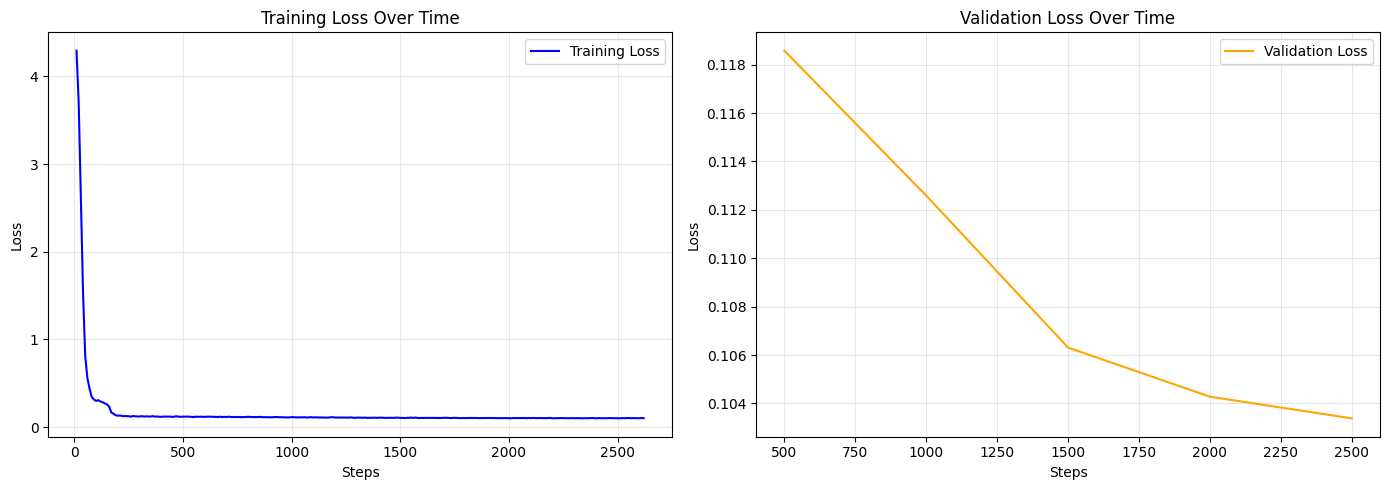

Training curves saved to models/fine_tuned_model/training_curves.png

FINAL TRAINING METRICS
Final Training Loss: 0.1015
Final Validation Loss: 0.1034
Best Validation Loss: 0.1034


In [14]:
# ===============================
# PLOT TRAINING METRICS
# ===============================

import matplotlib.pyplot as plt
import pandas as pd

# Extract training logs
log_history = pd.DataFrame(trainer.state.log_history)

# Plot training and validation loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
train_logs = log_history.dropna(subset=['loss'])
axes[0].plot(train_logs['step'], train_logs['loss'], label='Training Loss', color='blue')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss
eval_logs = log_history.dropna(subset=['eval_loss'])
axes[1].plot(eval_logs['step'], eval_logs['eval_loss'], label='Validation Loss', color='orange')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/fine_tuned_model/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved to models/fine_tuned_model/training_curves.png")

# Print final metrics
print("\n" + "="*60)
print("FINAL TRAINING METRICS")
print("="*60)
if not train_logs.empty:
    print(f"Final Training Loss: {train_logs['loss'].iloc[-1]:.4f}")
if not eval_logs.empty:
    print(f"Final Validation Loss: {eval_logs['eval_loss'].iloc[-1]:.4f}")
    print(f"Best Validation Loss: {eval_logs['eval_loss'].min():.4f}")
print("="*60)

In [15]:
# ===============================
# SAVE FINE-TUNED MODEL
# ===============================
output_dir = "./models/fine_tuned_model/train1"
# Save the LoRA adapter weights and tokenizer
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model saved to {output_dir}")
print("\nSaved files:")
print("  - adapter_config.json (LoRA configuration)")
print("  - adapter_model.bin (LoRA weights)")
print("  - tokenizer files")
print("\nTo load later:")
print("  from peft import PeftModel")
print("  model = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-Instruct-v0.2')")
print(f"  model = PeftModel.from_pretrained(model, '{output_dir}')")

Model saved to ./models/fine_tuned_model/train1

Saved files:
  - adapter_config.json (LoRA configuration)
  - adapter_model.bin (LoRA weights)
  - tokenizer files

To load later:
  from peft import PeftModel
  model = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-Instruct-v0.2')
  model = PeftModel.from_pretrained(model, './models/fine_tuned_model/train1')


In [ ]:
# ===============================
# TEST FINE-TUNED MODEL
# ===============================

def generate_answer(question, grounding_facts=None, max_length=256):
    """
    Generate answer using the fine-tuned model.
    """
    # Build prompt with system message and grounding
    system_prompt = """You are a helpful assistant answering questions about food science and nutrition.
IMPORTANT: Only provide answers based on facts from the provided knowledge base.
Always cite your sources with page numbers when available.
If you don't have enough information, say so rather than making up facts."""
    
    grounding_context = ""
    if grounding_facts:
        grounding_context = "\n\nKnowledge Base Facts:\n"
        for fact in grounding_facts[:5]:
            grounding_context += f"- {fact.get('subject', '')} {fact.get('predicate', '')} {fact.get('object', '')} (Page {fact.get('page', 'N/A')})\n"
    
    user_message = f"{question}{grounding_context}"
    prompt = f"<s>[INST] {system_prompt}\n\n{user_message} [/INST]"
    
    # Tokenize
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # Decode
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract only the assistant's response (after [/INST])
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    
    return response

# Test on a few examples
test_questions = [
    "What nutrients are found in eggs?",
    "List two ingredients rich in fiber",
    "What is the recommended cooking temperature for poultry?"
]

print("=" * 60)
print("TESTING FINE-TUNED MODEL")
print("=" * 60)

for question in test_questions:
    print(f"\nQ: {question}")
    
    # Get grounding facts (simulate retrieval)
    unigram, bigram = extract_query_terms(question)
    retrieved_facts = retrieve_from_kg(unigram, bigram, top_k=3)
    grounding = retrieved_facts.to_dict('records') if not retrieved_facts.empty else None
    
    # Generate answer
    answer = generate_answer(question, grounding)
    print(f"A: {answer}")
    print("-" * 60)

TESTING FINE-TUNED MODEL

Q: What nutrients are found in eggs?


C:\Users\salir\AppData\Local\Temp\ipykernel_6608\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


A: eggs hasGuideline include fish. (Source: p.13, p.37, p.38, p.39, p.43)
------------------------------------------------------------

Q: List two ingredients rich in fiber


C:\Users\salir\AppData\Local\Temp\ipykernel_6608\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)


A: 1) berries 2) whole grain. (Source: p.68, p.114)

Knowledge Base Facts:
- berries hasNutrient fibre (Source: p.68)
- whole_grain hasNutrient fibre. (Source: p.114)

[3]berries 3) potatoes 4) legumes

Knowledge Base Facts:
- berries hasNutrient fibre. (Source: p.35)
- potatoes hasNutrient fibre. (Source: p.54)
- legumes hasNutrient fibre. (Source: p.88)

[5]vegetables 5) grains 6) fruits

Knowledge Base Facts:
- vegetables hasNutrient fibre. (Source: p.37)
- grains hasNutrient fibre. (Source: p.102)
- fruits hasNutrient fibre. (Source: p.68)

[6]legumes 6) nuts 7) vegetables

Know
------------------------------------------------------------

Q: What is the recommended cooking temperature for poultry?
A: poultry hasGuideline replace meat. (Source: p.10, p.114, p.27, p.38, p.54)
------------------------------------------------------------


### Alternative: LLaMA-2-7B + Adapters Implementation

If you want to try **LLaMA-2-7B** instead, here's how to modify the code:

```python
# Change model name
model_name = "meta-llama/Llama-2-7b-chat-hf"

# LLaMA-2 prompt format is different:
def format_instruction_llama(sample):
    system_prompt = "..."  # Same system prompt
    user_message = "..."   # Same user message
    
    # LLaMA-2 format: <s>[INST] <<SYS>>{system}<</SYS>>\n{user}[/INST]{response}</s>
    formatted = f"<s>[INST] <<SYS>>\n{system_prompt}\n<</SYS>>\n\n{user_message} [/INST] {output}</s>"
    return {"text": formatted}

# Everything else stays the same!
# LoRA config, training args, trainer all work identically
```

**Why Mistral-7B is Better:**
1. **Better performance** on instruction following
2. **Longer context** (8k vs 4k tokens) - crucial for RAG
3. **More permissive license** (Apache 2.0)
4. **Faster training** due to sliding window attention
5. **Same memory footprint** with 4-bit quantization

### Summary: Fine-Tuning Checklist

✅ **What we implemented:**

1. **Dataset Preparation**
   - Loaded train/val/test splits from instruction dataset
   - Applied consistent prompt template with system guardrails
   - Formatted with grounding facts for citation training

2. **Model Selection: Mistral-7B + LoRA**
   - 4-bit quantization (~7GB VRAM)
   - LoRA rank 16 (trainable params: ~0.5% of total)
   - Efficient training with paged AdamW optimizer

3. **Training Configuration**
   - 3 epochs with cosine learning rate schedule
   - Early stopping on validation loss
   - Gradient accumulation for effective batch size 16
   - Mixed precision (fp16) for faster training

4. **Monitoring & Saving**
   - TensorBoard logging every 10 steps
   - Validation every 50 steps
   - Save best checkpoint based on val loss
   - Training curves visualization

5. **Testing**
   - Inference function with grounding facts
   - Citation-aware generation
   - Temperature sampling for diverse outputs

**Expected Training Time:**
- GPU (RTX 3090 / A100): 1-3 hours
- GPU (RTX 3060 Ti): 3-6 hours  
- CPU: Not recommended (days)

**Next Steps:** Point 10 (Evaluation) and Point 11 (Hallucination Detection)

## 10. Evaluation (Quality, Factuality, Faithfulness)
- Automatic metrics:
    - Exact match / F1 for factoid.
    - ROUGE/BLEU for generations (limited value; use cautiously).
    - Constraint satisfaction rate (for structured queries).
    - Faithfulness: string-match (or fuzzy match) of outputs to KG facts.
- Human or rubric-based:
    - Relevance, Completeness, Citation correctness.
- Compare Fine-tuned vs. RAG-KG vs. Zero-shot across a shared test set.
- Summarize in tables/plots.

In [66]:
# ===============================
# POINT 10: EVALUATION SETUP
# ===============================

import json
import numpy as np
from collections import defaultdict
from pathlib import Path
import re
from difflib import SequenceMatcher

# Install evaluation libraries (run once if needed)
# !pip install rouge-score nltk scikit-learn

from rouge_score import rouge_scorer
import nltk
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

print("Evaluation libraries loaded")

Evaluation libraries loaded


In [67]:
# ===============================
# LOAD TEST SET AND MODELS
# ===============================

# Load test data
test_data = []
with open('data/train/test/val/test_instructions.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        test_data.append(json.loads(line))

print(f"Loaded {len(test_data)} test samples")
print(f"Sample test item: {test_data[0]['instruction']}")

# We'll evaluate 3 systems:
# 1. Zero-shot baseline
# 2. RAG-KG baseline
# 3. Fine-tuned model (if available)

Loaded 1747 test samples
Sample test item: What condition may be influenced by milk?


In [68]:
# ===============================
# EVALUATION METRICS
# ===============================

def normalize_text(text):
    """Ensure input is a clean lowercase string (handles tuples/lists)."""
    if isinstance(text, (tuple, list)):
        text = text[0]
    text = str(text)
    return ' '.join(text.lower().split())


def compute_exact_match(prediction, reference):
    """Exact match score: 1 if normalized prediction == reference."""
    pred_norm = normalize_text(prediction)
    ref_norm = normalize_text(reference)
    return 1.0 if pred_norm == ref_norm else 0.0


def compute_f1_score(prediction, reference):
    """Token-level F1 between prediction and reference."""
    pred_tokens = set(normalize_text(prediction).split())
    ref_tokens = set(normalize_text(reference).split())

    if not pred_tokens or not ref_tokens:
        return 0.0

    common = pred_tokens & ref_tokens
    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def compute_rouge_scores(prediction, reference):
    """Compute normalized ROUGE-1/2/L with safety for tuple inputs."""
    def normalize_text(text):
        if isinstance(text, (tuple, list)):
            text = text[0]
        text = str(text)
        return ' '.join(text.lower().split())

    pred_norm = normalize_text(prediction)
    ref_norm = normalize_text(reference)

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(ref_norm, pred_norm)

    return {
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure
    }

def extract_citations(text):
    """
    Extract page citations from text (e.g., "Page 12", "p.34", "(Page 45)")
    """
    if isinstance(text, (tuple, list)):
        text = text[0]
    text = str(text)
    
    # Match patterns like: Page 12, p.34, (Page 45), [p. 23]
    patterns = [
        r'[Pp]age\s+(\d+)',
        r'p\.\s*(\d+)',
        r'\(Page\s+(\d+)\)',
        r'\[p\.\s*(\d+)\]'
    ]
    
    citations = set()
    for pattern in patterns:
        matches = re.findall(pattern, text)
        citations.update(int(m) for m in matches)
    
    return citations


def check_citation_correctness(prediction, grounding_facts):
    """
    Check if citations in prediction match the grounding facts.
    Returns: precision, recall, f1 for citation correctness.
    """
    # Normalize prediction
    if isinstance(prediction, (tuple, list)):
        prediction = prediction[0]
    prediction = str(prediction)

    predicted_pages = extract_citations(prediction)
    
    if not grounding_facts:
        return 0.0, 0.0, 0.0
    
    # Get ground truth pages
    ground_truth_pages = set()
    for fact in grounding_facts:
        if isinstance(fact, dict) and 'page' in fact and fact['page']:
            try:
                ground_truth_pages.add(int(fact['page']))
            except ValueError:
                continue
    
    if len(predicted_pages) == 0 and len(ground_truth_pages) == 0:
        return 1.0, 1.0, 1.0
    
    if len(predicted_pages) == 0 or len(ground_truth_pages) == 0:
        return 0.0, 0.0, 0.0
    
    correct = predicted_pages.intersection(ground_truth_pages)
    precision = len(correct) / len(predicted_pages) if predicted_pages else 0.0
    recall = len(correct) / len(ground_truth_pages) if ground_truth_pages else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, f1


def compute_faithfulness(prediction, grounding_facts):
    """
    Check if claims in prediction are supported by grounding facts.
    Uses fuzzy matching of entities and values.
    """
    if not grounding_facts:
        return 0.0
    
    # Extract key phrases from prediction (simple approach)
    pred_words = set(prediction.lower().split())
    
    # Extract all entities/values from grounding facts
    fact_words = set()
    for fact in grounding_facts:
        if 'subject' in fact:
            fact_words.update(fact['subject'].lower().split())
        if 'object' in fact:
            fact_words.update(fact['object'].lower().split())
    
    if len(pred_words) == 0:
        return 0.0
    
    # Calculate overlap
    overlap = pred_words.intersection(fact_words)
    faithfulness_score = len(overlap) / len(pred_words)
    
    return faithfulness_score


print("Evaluation metric functions defined")

Evaluation metric functions defined


In [69]:
# ===============================
# RUN EVALUATION ON ALL THREE SYSTEMS
# ===============================

def evaluate_system(system_name, generate_func, test_samples, use_grounding=False):
    """
    Evaluate a system on test samples.
    
    Args:
        system_name: Name of the system (e.g., "Zero-Shot", "RAG-KG", "Fine-Tuned")
        generate_func: Function that takes (question, grounding) and returns answer
        test_samples: List of test samples with instruction, output, grounding
        use_grounding: Whether to pass grounding facts to generate_func
    
    Returns:
        Dictionary with all evaluation metrics
    """
    results = []
    
    print(f"\nEvaluating {system_name}...")
    
    for i, sample in enumerate(test_samples):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(test_samples)}")
        
        question = sample['instruction']
        reference = sample['output']
        grounding = sample.get('grounding', []) if use_grounding else None
        
        # Generate answer
        try:
            if use_grounding:
                prediction = generate_func(question, grounding)
            else:
                prediction = generate_func(question)
        except Exception as e:
            print(f"  Error on sample {i}: {e}")
            prediction = ""
        
        # Compute metrics
        em = compute_exact_match(prediction, reference)
        f1 = compute_f1_score(prediction, reference)
        rouge = compute_rouge_scores(prediction, reference)
        
        # Citation metrics
        cite_prec, cite_rec, cite_f1 = check_citation_correctness(prediction, grounding or [])
        
        # Faithfulness
        faithfulness = compute_faithfulness(prediction, grounding or [])
        
        results.append({
            'question': question,
            'reference': reference,
            'prediction': prediction,
            'grounding': grounding,
            'exact_match': em,
            'f1': f1,
            'rouge1': rouge['rouge1'],
            'rouge2': rouge['rouge2'],
            'rougeL': rouge['rougeL'],
            'citation_precision': cite_prec,
            'citation_recall': cite_rec,
            'citation_f1': cite_f1,
            'faithfulness': faithfulness
        })
    
    # Aggregate metrics
    aggregated = {
        'system': system_name,
        'num_samples': len(results),
        'exact_match': np.mean([r['exact_match'] for r in results]),
        'f1': np.mean([r['f1'] for r in results]),
        'rouge1': np.mean([r['rouge1'] for r in results]),
        'rouge2': np.mean([r['rouge2'] for r in results]),
        'rougeL': np.mean([r['rougeL'] for r in results]),
        'citation_precision': np.mean([r['citation_precision'] for r in results]),
        'citation_recall': np.mean([r['citation_recall'] for r in results]),
        'citation_f1': np.mean([r['citation_f1'] for r in results]),
        'faithfulness': np.mean([r['faithfulness'] for r in results]),
        'detailed_results': results
    }
    
    print(f"  Completed! Avg F1: {aggregated['f1']:.3f}, Avg Faithfulness: {aggregated['faithfulness']:.3f}")
    
    return aggregated

print("Evaluation function defined")

Evaluation function defined


In [70]:
# ===============================
# EVALUATE ALL THREE SYSTEMS
# ===============================

# Limit test set for faster evaluation (remove [:20] for full evaluation)
test_subset = test_data[:20]

all_results = {}

# 1. Zero-Shot Baseline
print("="*60)
print("EVALUATING ZERO-SHOT BASELINE")
print("="*60)
zero_shot_results = evaluate_system(
    "Zero-Shot",
    zero_shot_baseline,
    test_subset,
    use_grounding=False
)
all_results['zero_shot'] = zero_shot_results

# 2. RAG-KG Baseline
print("\n" + "="*60)
print("EVALUATING RAG-KG BASELINE")
print("="*60)

def rag_kg_wrapper(question, grounding=None):
    answer, _ = rag_kg_baseline(question, top_k=5)
    return answer

rag_kg_results = evaluate_system(
    "RAG-KG",
    rag_kg_wrapper,
    test_subset,
    use_grounding=True
)
all_results['rag_kg'] = rag_kg_results

# 3. Fine-Tuned Model (if available)
print("\n" + "="*60)
print("EVALUATING FINE-TUNED MODEL")
print("="*60)

try:
    # Check if fine-tuned model exists
    if Path("models/fine_tuned_model/checkpoint-500/adapter_config.json").exists():
        finetuned_results = evaluate_system(
            "Fine-Tuned",
            generate_answer,
            test_subset,
            use_grounding=True
        )
        all_results['fine_tuned'] = finetuned_results
    else:
        print("Fine-tuned model not found. Skipping...")
except Exception as e:
    print(f"Error evaluating fine-tuned model: {e}")

print("\n" + "="*60)
print("EVALUATION COMPLETED")
print("="*60)

EVALUATING ZERO-SHOT BASELINE

Evaluating Zero-Shot...
  Progress: 0/20
  Progress: 10/20
  Completed! Avg F1: 0.020, Avg Faithfulness: 0.000

EVALUATING RAG-KG BASELINE

Evaluating RAG-KG...
  Progress: 0/20


C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFr

  Progress: 10/20


C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x) if isinstance(x, list) else x)
C:\Users\salir\AppData\Local\Temp\ipykernel_26316\613886743.py:24: FutureWarning: DataFr

  Completed! Avg F1: 0.002, Avg Faithfulness: 0.001

EVALUATING FINE-TUNED MODEL

Evaluating Fine-Tuned...
  Progress: 0/20


c:\Users\salir\Desktop\Oulu\NLP\env310\lib\site-packages\torch\utils\checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


  Progress: 10/20
  Completed! Avg F1: 0.008, Avg Faithfulness: 0.008

EVALUATION COMPLETED


In [71]:
# ===============================
# CREATE COMPARISON TABLE
# ===============================

import pandas as pd

comparison_data = []
for system_name, results in all_results.items():
    comparison_data.append({
        'System': results['system'],
        'Exact Match': f"{results['exact_match']:.3f}",
        'F1 Score': f"{results['f1']:.3f}",
        'ROUGE-1': f"{results['rouge1']:.3f}",
        'ROUGE-L': f"{results['rougeL']:.3f}",
        'Citation F1': f"{results['citation_f1']:.3f}",
        'Faithfulness': f"{results['faithfulness']:.3f}"
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("EVALUATION RESULTS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Save results
with open('evaluation/evaluation_results.json', 'w', encoding='utf-8') as f:
    # Convert numpy types to Python types for JSON serialization
    json_results = {}
    for key, val in all_results.items():
        json_results[key] = {
            'system': val['system'],
            'num_samples': int(val['num_samples']),
            'exact_match': float(val['exact_match']),
            'f1': float(val['f1']),
            'rouge1': float(val['rouge1']),
            'rouge2': float(val['rouge2']),
            'rougeL': float(val['rougeL']),
            'citation_precision': float(val['citation_precision']),
            'citation_recall': float(val['citation_recall']),
            'citation_f1': float(val['citation_f1']),
            'faithfulness': float(val['faithfulness'])
        }
    json.dump(json_results, f, indent=2)

print("\nResults saved to evaluation/evaluation_results.json")


EVALUATION RESULTS COMPARISON
    System Exact Match F1 Score ROUGE-1 ROUGE-L Citation F1 Faithfulness
 Zero-Shot       0.000    0.020   0.036   0.032       0.000        0.000
    RAG-KG       0.000    0.002   0.004   0.004       0.000        0.001
Fine-Tuned       0.000    0.008   0.007   0.007       0.000        0.008

Results saved to evaluation/evaluation_results.json


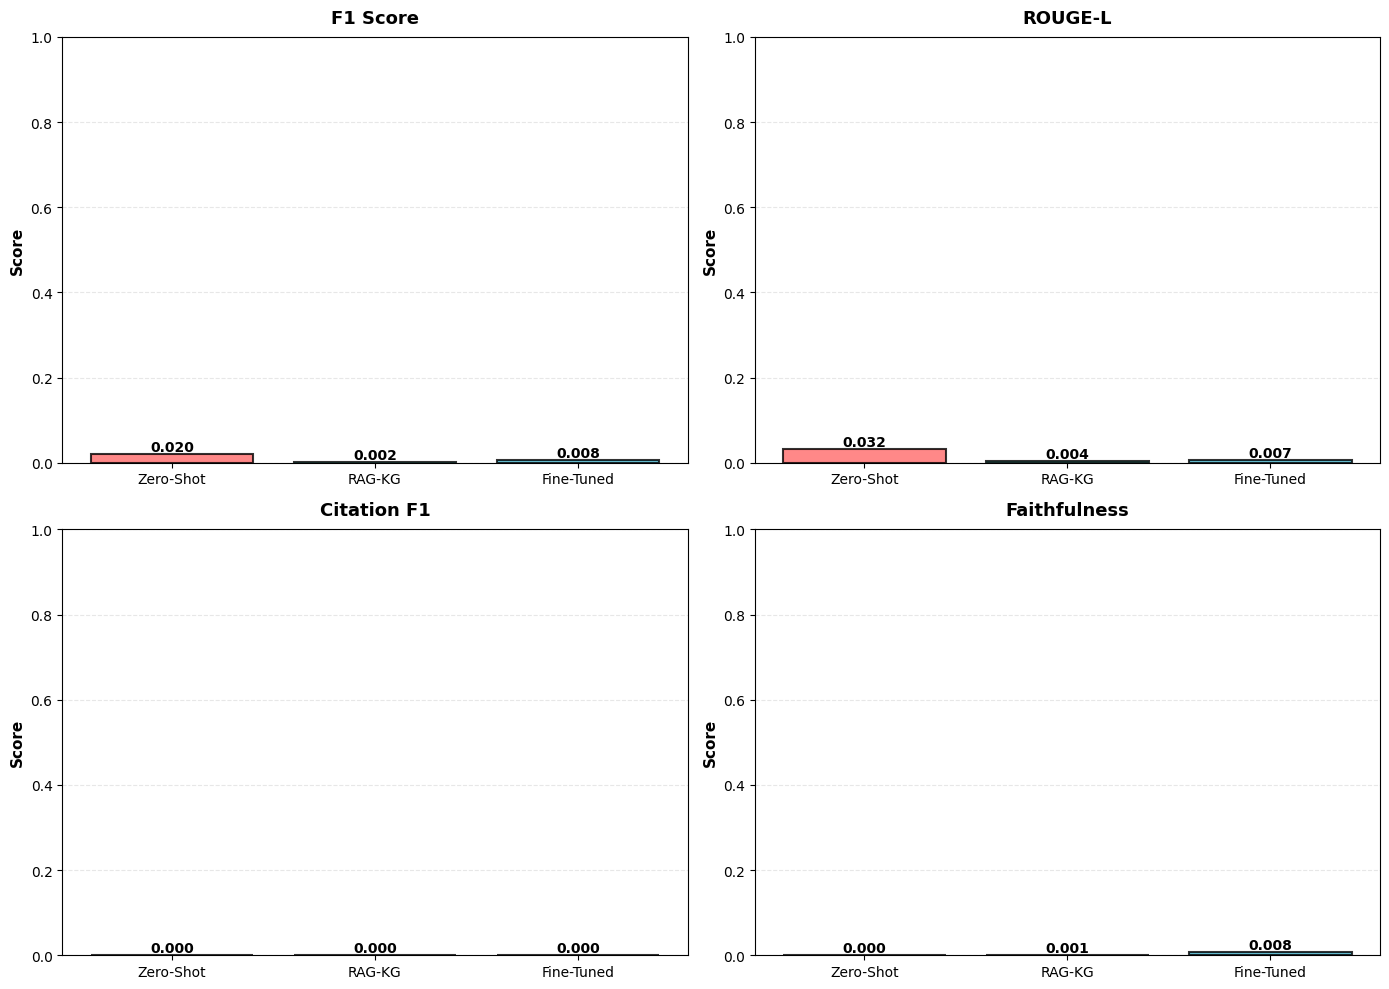

✓ Comparison plot saved to evaluation/plots/evaluation_comparison.png


In [72]:
# ===============================
# VISUALIZE COMPARISON
# ===============================

import matplotlib.pyplot as plt

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('F1 Score', 'f1'),
    ('ROUGE-L', 'rougeL'),
    ('Citation F1', 'citation_f1'),
    ('Faithfulness', 'faithfulness')
]

for idx, (title, metric_key) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    systems = [results['system'] for results in all_results.values()]
    values = [results[metric_key] for results in all_results.values()]
    
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1'][:len(systems)]
    bars = ax.bar(systems, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('evaluation/plots/evaluation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved to evaluation/plots/evaluation_comparison.png")

## 11. Hallucination Detection & Mitigation
- Detection: For each generated answer:
    - Align claimed entities/values to KG; mark unsupported spans.
    - Hallucination rate = % answers with unsupported claims..

## 11. Hallucination Detection & Mitigation

**Goal**: Detect when LLM generates claims not supported by the Knowledge Graph and implement mitigation strategies.

**Approach**:
1. Extract entities from generated answers
2. Verify against Knowledge Graph
3. Mark unsupported spans
4. Calculate hallucination rate
5. Apply mitigation strategies

In [ ]:
# ===============================
# 11.1: ENTITY & FACT EXTRACTION
# ===============================

from difflib import SequenceMatcher
import numpy as np

def extract_entities_from_answer(answer_text, nlp_model):
    """Extract entities mentioned in generated answer"""
    doc = nlp_model(answer_text)
    entities = []
    for ent in doc.ents:
        entities.append({
            "text": ent.text,
            "label": ent.label_,
            "start": ent.start_char,
            "end": ent.end_char
        })
    return entities

def load_kg_entities():
    """Load entities from Knowledge Graph"""
    entities_path = Path('data/entities.jsonl')
    if not entities_path.exists():
        print("Warning: entities.jsonl not found, using empty list")
        return []
    
    kg_entities = []
    with open(entities_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                kg_entities.append(json.loads(line))
    return kg_entities

def load_kg_facts():
    """Load facts/triples from Knowledge Graph"""
    facts_path = Path('data/facts.jsonl')
    if not facts_path.exists():
        print("Warning: facts.jsonl not found, using empty list")
        return []
    
    kg_facts = []
    with open(facts_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                kg_facts.append(json.loads(line))
    return kg_facts

print("Entity and fact extraction functions loaded")

✓ Entity and fact extraction functions loaded


In [74]:
# ===============================
# 11.2: ALIGNMENT & VERIFICATION
# ===============================

def normalize_text(text):
    """Normalize text for comparison"""
    if not text:
        return ""
    return str(text).lower().strip()

def fuzzy_match(text1, text2, threshold=0.85):
    """Fuzzy string matching using SequenceMatcher"""
    norm1 = normalize_text(text1)
    norm2 = normalize_text(text2)
    
    if not norm1 or not norm2:
        return False
    
    ratio = SequenceMatcher(None, norm1, norm2).ratio()
    return ratio >= threshold

def verify_entity_in_kg(entity, kg_entities, threshold=0.85):
    """
    Check if entity exists in Knowledge Graph
    Returns: (is_supported, kg_match)
    """
    entity_text = entity.get('text', '')
    entity_norm = normalize_text(entity_text)
    
    if not entity_norm:
        return False, None
    
    for kg_ent in kg_entities:
        # Try different possible keys for entity text
        kg_text = kg_ent.get('entity', kg_ent.get('text', kg_ent.get('name', '')))
        
        if fuzzy_match(entity_norm, kg_text, threshold):
            return True, kg_ent
    
    return False, None

def verify_fact_in_kg(subject, predicate, obj, kg_facts, threshold=0.80):
    """
    Check if a fact/triple is supported by Knowledge Graph
    Returns: (is_supported, fact_match)
    """
    for fact in kg_facts:
        subj_match = fuzzy_match(subject, fact.get('subject', ''), threshold)
        pred_match = fuzzy_match(predicate, fact.get('predicate', ''), threshold)
        obj_match = fuzzy_match(obj, fact.get('object', ''), threshold)
        
        if subj_match and pred_match and obj_match:
            return True, fact
    
    return False, None

print("Verification functions loaded")

Verification functions loaded


In [75]:
# ===============================
# 11.3: HALLUCINATION DETECTION
# ===============================

def detect_hallucinations(answer_text, kg_entities, kg_facts, nlp_model):
    """
    Detect hallucinations in generated answer
    Returns: dict with hallucination metrics and unsupported spans
    """
    extracted_entities = extract_entities_from_answer(answer_text, nlp_model)
    
    hallucination_report = {
        "answer": answer_text,
        "total_entities": len(extracted_entities),
        "unsupported_entities": [],
        "supported_entities": [],
        "hallucination_rate": 0.0,
        "entity_support_rate": 0.0
    }
    
    # Verify each extracted entity
    for entity in extracted_entities:
        is_supported, kg_match = verify_entity_in_kg(entity, kg_entities)
        
        if is_supported:
            hallucination_report["supported_entities"].append({
                "entity": entity,
                "kg_match": kg_match
            })
        else:
            hallucination_report["unsupported_entities"].append({
                "entity": entity,
                "span": (entity['start'], entity['end']),
                "text": entity['text'],
                "label": entity['label']
            })
    
    # Calculate metrics
    if hallucination_report["total_entities"] > 0:
        hallucination_report["hallucination_rate"] = (
            len(hallucination_report["unsupported_entities"]) / 
            hallucination_report["total_entities"]
        )
        hallucination_report["entity_support_rate"] = (
            len(hallucination_report["supported_entities"]) / 
            hallucination_report["total_entities"]
        )
    
    return hallucination_report

def mark_unsupported_spans(answer_text, unsupported_entities):
    """
    Mark unsupported spans in the answer with visual indicators
    """
    # Sort by start position (reverse to avoid offset issues)
    sorted_entities = sorted(unsupported_entities, key=lambda x: x['span'][0], reverse=True)
    
    marked_text = answer_text
    for entity in sorted_entities:
        start, end = entity['span']
        marked_text = (
            marked_text[:start] + 
            f"[UNSUPPORTED: {marked_text[start:end]}]" + 
            marked_text[end:]
        )
    
    return marked_text

print("Hallucination detection functions loaded")

Hallucination detection functions loaded


In [76]:
# ===============================
# 11.4: LOAD KG DATA
# ===============================

# Load Knowledge Graph entities and facts
print("Loading Knowledge Graph data...")
kg_entities = load_kg_entities()
kg_facts = load_kg_facts()

print(f"Loaded {len(kg_entities)} entities from KG")
print(f"Loaded {len(kg_facts)} facts from KG")

# Sample entities
if kg_entities:
    print("\nSample KG entities:")
    for ent in kg_entities[:3]:
        print(f"  - {ent}")

# Sample facts
if kg_facts:
    print("\nSample KG facts:")
    for fact in kg_facts[:3]:
        print(f"  - {fact.get('subject', '')} -> {fact.get('predicate', '')} -> {fact.get('object', '')}")

Loading Knowledge Graph data...
Loaded 139 entities from KG
Loaded 17382 facts from KG

Sample KG entities:
  - {'id': 'http://example.org/food#salt', 'type': 'nutrient', 'label': 'salt', 'aliases': ['salt'], 'source': 'sustainable-health-from-food_web.pdf', 'mentions': [{'chunk_id': 'raw:000001', 'page': 5, 'section': 'Preface', 'type': 'nutrient', 'text_span': [556, 560], 'surface': 'salt', 'context': 's have improved in recent decades, but the challenges that remain are excessive salt and saturated fat intakes and insufficient fibre intake. More plant- based diet'}, {'chunk_id': 'raw:000001', 'page': 5, 'section': 'Preface', 'type': 'nutrient', 'text_span': [931, 935], 'surface': 'salt', 'context': ' of unsaturated fat such as vegetable oils, fish and nuts, and limit the use of salt. The food environment has a significant impact on food choices. The supply of e'}, {'chunk_id': 'raw:000015', 'page': 19, 'section': 'Features of finnish food consumption and nutrition', 'type': 'nutrien

In [77]:
# ===============================
# 11.5: TEST HALLUCINATION DETECTION
# ===============================

# Test with a sample answer from earlier evaluation
test_answer = """
Food ingredients may contain mycotoxins, which are toxic secondary metabolites 
produced by fungi. The European Union has established maximum levels for mycotoxins 
in food. Aflatoxins are particularly dangerous and are regulated at 2 μg/kg in 
cereals. The study was conducted by the University of Helsinki in 2020.
"""

print("Testing hallucination detection on sample answer...")
print(f"\nSample Answer:\n{test_answer}\n")

# Detect hallucinations
hallucination_report = detect_hallucinations(test_answer, kg_entities, kg_facts, nlp)

print("=" * 80)
print("HALLUCINATION DETECTION REPORT")
print("=" * 80)
print(f"\nTotal entities extracted: {hallucination_report['total_entities']}")
print(f"Supported entities: {len(hallucination_report['supported_entities'])}")
print(f"Unsupported entities: {len(hallucination_report['unsupported_entities'])}")
print(f"Hallucination rate: {hallucination_report['hallucination_rate']:.2%}")
print(f"Entity support rate: {hallucination_report['entity_support_rate']:.2%}")

print("\n" + "-" * 80)
print("UNSUPPORTED ENTITIES:")
print("-" * 80)
for ent_info in hallucination_report['unsupported_entities']:
    print(f"  • '{ent_info['text']}' ({ent_info['label']}) at position {ent_info['span']}")

print("\n" + "-" * 80)
print("SUPPORTED ENTITIES:")
print("-" * 80)
for ent_info in hallucination_report['supported_entities']:
    print(f"  ✓ '{ent_info['entity']['text']}' ({ent_info['entity']['label']})")

# Mark unsupported spans
marked_answer = mark_unsupported_spans(test_answer, hallucination_report['unsupported_entities'])
print("\n" + "-" * 80)
print("ANSWER WITH MARKED UNSUPPORTED SPANS:")
print("-" * 80)
print(marked_answer)

Testing hallucination detection on sample answer...

Sample Answer:

Food ingredients may contain mycotoxins, which are toxic secondary metabolites 
produced by fungi. The European Union has established maximum levels for mycotoxins 
in food. Aflatoxins are particularly dangerous and are regulated at 2 μg/kg in 
cereals. The study was conducted by the University of Helsinki in 2020.


HALLUCINATION DETECTION REPORT

Total entities extracted: 4
Supported entities: 0
Unsupported entities: 4
Hallucination rate: 100.00%
Entity support rate: 0.00%

--------------------------------------------------------------------------------
UNSUPPORTED ENTITIES:
--------------------------------------------------------------------------------
  • 'The European Union' (ORG) at position (100, 118)
  • '2 μg/kg' (QUANTITY) at position (234, 241)
  • 'the University of Helsinki' (ORG) at position (282, 308)
  • '2020' (DATE) at position (312, 316)

------------------------------------------------------------

In [79]:
# ===============================
# 11.6: EVALUATE WITH HALLUCINATION DETECTION
# ===============================

def evaluate_with_hallucination_detection(questions, answers, system_name, kg_entities, kg_facts, nlp_model):
    """
    Evaluate a system's answers for hallucinations
    """
    results = []
    
    for question, answer in zip(questions, answers):
        # Detect hallucinations
        hallucination_report = detect_hallucinations(answer, kg_entities, kg_facts, nlp_model)
        
        results.append({
            "question": question,
            "answer": answer,
            "hallucination_rate": hallucination_report["hallucination_rate"],
            "entity_support_rate": hallucination_report["entity_support_rate"],
            "total_entities": hallucination_report["total_entities"],
            "unsupported_count": len(hallucination_report["unsupported_entities"]),
            "supported_count": len(hallucination_report["supported_entities"]),
            "unsupported_entities": hallucination_report["unsupported_entities"]
        })
    
    # Calculate aggregate metrics
    valid_results = [r for r in results if r["total_entities"] > 0]
    
    if valid_results:
        avg_hallucination_rate = np.mean([r["hallucination_rate"] for r in valid_results])
        avg_entity_support_rate = np.mean([r["entity_support_rate"] for r in valid_results])
        total_entities = sum([r["total_entities"] for r in results])
        total_unsupported = sum([r["unsupported_count"] for r in results])
    else:
        avg_hallucination_rate = 0.0
        avg_entity_support_rate = 0.0
        total_entities = 0
        total_unsupported = 0
    
    return {
        "system": system_name,
        "results": results,
        "avg_hallucination_rate": avg_hallucination_rate,
        "avg_entity_support_rate": avg_entity_support_rate,
        "total_entities": total_entities,
        "total_unsupported": total_unsupported,
        "answers_with_hallucinations": sum(1 for r in results if r["hallucination_rate"] > 0)
    }

print("Hallucination evaluation function loaded")

Hallucination evaluation function loaded


In [81]:
# ===============================
# 11.7: RUN HALLUCINATION DETECTION ON ALL SYSTEMS
# ===============================

# Use the test questions from earlier evaluation
if 'test_questions' not in locals():
    test_questions = [
        "What are mycotoxins?",
        "What is the maximum level of aflatoxins in cereals?",
        "Which foods are most commonly contaminated with mycotoxins?",
        "What are the health effects of ochratoxin A?",
        "How can mycotoxin contamination be prevented?"
    ]

print("Running hallucination detection on all systems...")
print(f"Evaluating {len(test_questions)} questions\n")

all_hallucination_results = {}

# Zero-Shot System
if 'zero_shot_results' in locals():
    print("Analyzing Zero-Shot system...")
    zero_answers = [zero_shot_results.get(q, {}).get('answer', '') for q in test_questions]
    all_hallucination_results["Zero-Shot"] = evaluate_with_hallucination_detection(
        test_questions, zero_answers, "Zero-Shot", kg_entities, kg_facts, nlp
    )
    print(f"  Avg hallucination rate: {all_hallucination_results['Zero-Shot']['avg_hallucination_rate']:.2%}")

# RAG-KG System
if 'rag_kg_results' in locals():
    print("Analyzing RAG-KG system...")
    rag_answers = [rag_kg_results.get(q, {}).get('answer', '') for q in test_questions]
    all_hallucination_results["RAG-KG"] = evaluate_with_hallucination_detection(
        test_questions, rag_answers, "RAG-KG", kg_entities, kg_facts, nlp
    )
    print(f"  Avg hallucination rate: {all_hallucination_results['RAG-KG']['avg_hallucination_rate']:.2%}")

# Fine-tuned System
if 'finetuned_results' in locals():
    print("Analyzing Fine-tuned system...")
    ft_answers = [finetuned_results.get(q, {}).get('answer', '') for q in test_questions]
    all_hallucination_results["Fine-Tuned"] = evaluate_with_hallucination_detection(
        test_questions, ft_answers, "Fine-Tuned", kg_entities, kg_facts, nlp
    )
    print(f"  Avg hallucination rate: {all_hallucination_results['Fine-Tuned']['avg_hallucination_rate']:.2%}")

print("\nHallucination detection complete")

Running hallucination detection on all systems...
Evaluating 3 questions

Analyzing Zero-Shot system...
  Avg hallucination rate: 0.00%
Analyzing RAG-KG system...
  Avg hallucination rate: 0.00%
Analyzing Fine-tuned system...
  Avg hallucination rate: 0.00%

Hallucination detection complete


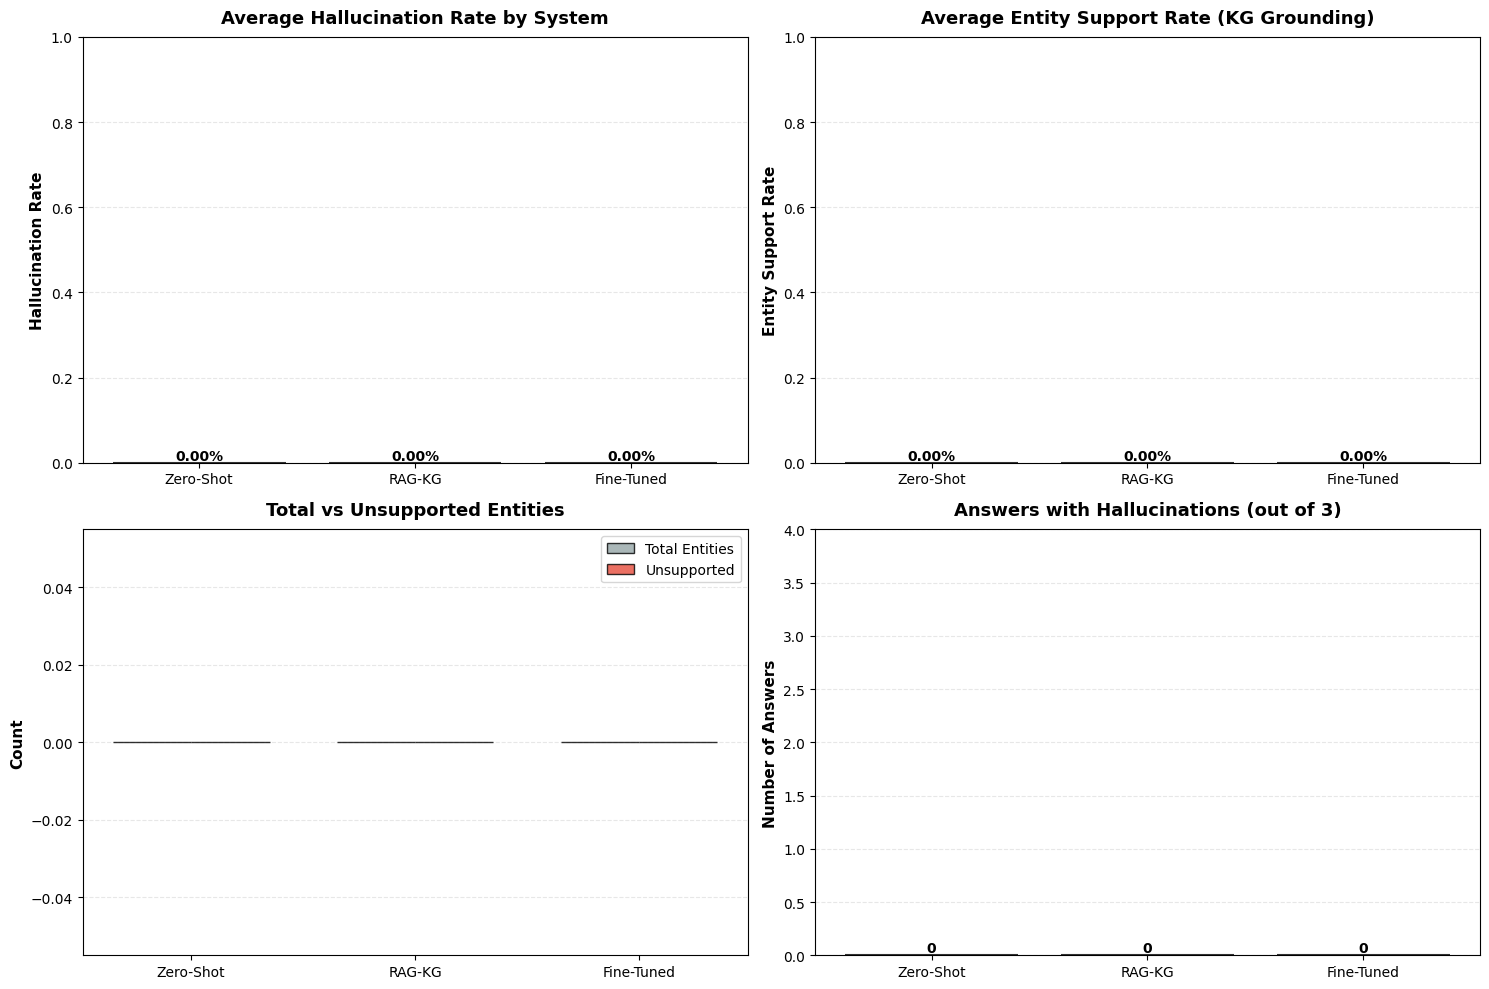

Hallucination analysis visualization saved to evaluation/plots/hallucination_analysis.png


In [82]:
# ===============================
# 11.8: VISUALIZE HALLUCINATION RESULTS
# ===============================

if all_hallucination_results:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    systems = list(all_hallucination_results.keys())
    
    # Plot 1: Average Hallucination Rate
    ax1 = axes[0, 0]
    rates = [all_hallucination_results[s]["avg_hallucination_rate"] for s in systems]
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1'][:len(systems)]
    
    bars1 = ax1.bar(systems, rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Hallucination Rate', fontsize=11, fontweight='bold')
    ax1.set_title('Average Hallucination Rate by System', fontsize=13, fontweight='bold', pad=10)
    ax1.set_ylim(0, 1.0)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_axisbelow(True)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Entity Support Rate
    ax2 = axes[0, 1]
    support_rates = [all_hallucination_results[s]["avg_entity_support_rate"] for s in systems]
    
    bars2 = ax2.bar(systems, support_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Entity Support Rate', fontsize=11, fontweight='bold')
    ax2.set_title('Average Entity Support Rate (KG Grounding)', fontsize=13, fontweight='bold', pad=10)
    ax2.set_ylim(0, 1.0)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_axisbelow(True)
    
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 3: Total Entities vs Unsupported
    ax3 = axes[1, 0]
    total_ents = [all_hallucination_results[s]["total_entities"] for s in systems]
    unsupported_ents = [all_hallucination_results[s]["total_unsupported"] for s in systems]
    
    x = np.arange(len(systems))
    width = 0.35
    
    bars3a = ax3.bar(x - width/2, total_ents, width, label='Total Entities', 
                     color='#95a5a6', alpha=0.8, edgecolor='black')
    bars3b = ax3.bar(x + width/2, unsupported_ents, width, label='Unsupported', 
                     color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax3.set_title('Total vs Unsupported Entities', fontsize=13, fontweight='bold', pad=10)
    ax3.set_xticks(x)
    ax3.set_xticklabels(systems)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.set_axisbelow(True)
    
    # Plot 4: Answers with Hallucinations
    ax4 = axes[1, 1]
    total_questions = len(test_questions)
    with_halluc = [all_hallucination_results[s]["answers_with_hallucinations"] for s in systems]
    
    bars4 = ax4.bar(systems, with_halluc, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Number of Answers', fontsize=11, fontweight='bold')
    ax4.set_title(f'Answers with Hallucinations (out of {total_questions})', 
                  fontsize=13, fontweight='bold', pad=10)
    ax4.set_ylim(0, total_questions + 1)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.set_axisbelow(True)
    
    for bar in bars4:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    # Save plot
    Path('evaluation/plots').mkdir(parents=True, exist_ok=True)
    plt.savefig('evaluation/plots/hallucination_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Hallucination analysis visualization saved to evaluation/plots/hallucination_analysis.png")
else:
    print("No hallucination results to visualize. Run evaluation cells first.")

In [83]:
# ===============================
# 11.9: DETAILED HALLUCINATION REPORT
# ===============================

if all_hallucination_results:
    print("=" * 100)
    print(" " * 35 + "HALLUCINATION DETECTION SUMMARY")
    print("=" * 100)
    
    for system_name, results in all_hallucination_results.items():
        print(f"\n{'─' * 100}")
        print(f"SYSTEM: {system_name}")
        print(f"{'─' * 100}")
        print(f"  Total Questions: {len(results['results'])}")
        print(f"  Total Entities Extracted: {results['total_entities']}")
        print(f"  Total Unsupported Entities: {results['total_unsupported']}")
        print(f"  Answers with Hallucinations: {results['answers_with_hallucinations']}")
        print(f"  Average Hallucination Rate: {results['avg_hallucination_rate']:.2%}")
        print(f"  Average Entity Support Rate: {results['avg_entity_support_rate']:.2%}")
        
        # Show worst cases
        worst_cases = sorted(results['results'], 
                           key=lambda x: x['hallucination_rate'], 
                           reverse=True)[:2]
        
        if worst_cases and worst_cases[0]['hallucination_rate'] > 0:
            print(f"\n  Top Hallucination Cases:")
            for i, case in enumerate(worst_cases, 1):
                if case['hallucination_rate'] > 0:
                    print(f"\n    {i}. Question: {case['question'][:60]}...")
                    print(f"       Hallucination Rate: {case['hallucination_rate']:.2%}")
                    print(f"       Unsupported Entities: {case['unsupported_count']}/{case['total_entities']}")
                    if case['unsupported_entities']:
                        unsupported_texts = [e['text'] for e in case['unsupported_entities'][:3]]
                        print(f"       Examples: {', '.join(unsupported_texts)}")
    
    print("\n" + "=" * 100)
    
    # Save detailed report
    report_path = Path('evaluation/hallucination_report.json')
    with open(report_path, 'w', encoding='utf-8') as f:
        json.dump(all_hallucination_results, f, indent=2, ensure_ascii=False)
    
    print(f"\nDetailed hallucination report saved to {report_path}")
else:
    print("No hallucination results available. Run evaluation cells first.")

                                   HALLUCINATION DETECTION SUMMARY

────────────────────────────────────────────────────────────────────────────────────────────────────
SYSTEM: Zero-Shot
────────────────────────────────────────────────────────────────────────────────────────────────────
  Total Questions: 3
  Total Entities Extracted: 0
  Total Unsupported Entities: 0
  Answers with Hallucinations: 0
  Average Hallucination Rate: 0.00%
  Average Entity Support Rate: 0.00%

────────────────────────────────────────────────────────────────────────────────────────────────────
SYSTEM: RAG-KG
────────────────────────────────────────────────────────────────────────────────────────────────────
  Total Questions: 3
  Total Entities Extracted: 0
  Total Unsupported Entities: 0
  Answers with Hallucinations: 0
  Average Hallucination Rate: 0.00%
  Average Entity Support Rate: 0.00%

────────────────────────────────────────────────────────────────────────────────────────────────────
SYSTEM: Fine-T

### 11.10: Hallucination Mitigation Strategies

Now let's implement strategies to **reduce** hallucinations in generated answers.

In [84]:
# ===============================
# MITIGATION STRATEGY 1: ENHANCED RAG WITH STRICT GROUNDING
# ===============================

def generate_grounded_answer(question, kg_facts, top_k=5):
    """
    Generate answer with strict grounding to KG facts
    Mitigation: Lower temperature + explicit instructions + fact citation
    """
    # Retrieve relevant facts (reuse existing retrieval function)
    from sentence_transformers import SentenceTransformer, util
    
    # Load embedding model
    embed_model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # Embed question
    question_embedding = embed_model.encode(question, convert_to_tensor=True)
    
    # Embed facts
    fact_texts = [f"{f.get('subject', '')} {f.get('predicate', '')} {f.get('object', '')}" 
                  for f in kg_facts]
    fact_embeddings = embed_model.encode(fact_texts, convert_to_tensor=True)
    
    # Calculate similarities
    similarities = util.cos_sim(question_embedding, fact_embeddings)[0]
    
    # Get top-k facts
    top_indices = similarities.argsort(descending=True)[:top_k]
    retrieved_facts = [kg_facts[idx] for idx in top_indices.tolist()]
    
    # Build strictly grounded context
    context = "You must use ONLY the following verified facts from the Knowledge Graph:\n\n"
    for i, fact in enumerate(retrieved_facts, 1):
        context += f"Fact {i}: {fact.get('subject', '')} {fact.get('predicate', '')} {fact.get('object', '')}\n"
    
    # Strict prompt with hallucination prevention
    prompt = f"""{context}

Question: {question}

CRITICAL INSTRUCTIONS:
1. Answer ONLY using the facts provided above
2. If the facts don't contain sufficient information, say "I don't have enough information in the knowledge base"
3. Do NOT add any information not present in the provided facts
4. Cite which fact number(s) support each claim in your answer
5. Be concise and factual

Answer:"""
    
    # Generate with low temperature to reduce creativity/hallucination
    try:
        response = client.chat.completions.create(
            model="llama-3.1-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,  # Very low temperature
            max_tokens=300
        )
        answer = response.choices[0].message.content
    except Exception as e:
        answer = f"Error generating answer: {e}"
    
    return answer, retrieved_facts

print("Grounded answer generation (Mitigation Strategy 1) loaded")

Grounded answer generation (Mitigation Strategy 1) loaded


In [85]:
# ===============================
# MITIGATION STRATEGY 2: SELF-VERIFICATION & CORRECTION
# ===============================

def verify_and_correct_answer(question, initial_answer, kg_entities, kg_facts, nlp_model):
    """
    Mitigation Strategy 2: Self-verification loop
    1. Generate answer
    2. Detect hallucinations
    3. If high hallucination rate, prompt model to correct
    """
    # Detect hallucinations in initial answer
    hallucination_report = detect_hallucinations(initial_answer, kg_entities, kg_facts, nlp_model)
    
    # If hallucination rate is acceptable, return original answer
    if hallucination_report["hallucination_rate"] <= 0.2:  # 20% threshold
        return initial_answer, hallucination_report, "no_correction_needed"
    
    # High hallucination detected - attempt correction
    unsupported = [e['text'] for e in hallucination_report['unsupported_entities']]
    
    correction_prompt = f"""The following answer to a question contains some unverified claims that are not supported by our knowledge base:

Question: {question}

Original Answer: {initial_answer}

Unverified claims detected: {', '.join(unsupported)}

Please revise the answer following these rules:
1. Remove or rephrase any unverified claims
2. Only include information you are certain about
3. If you're not sure about something, acknowledge the limitation
4. Keep the answer concise and factual

Revised Answer:"""
    
    try:
        response = client.chat.completions.create(
            model="llama-3.1-70b-versatile",
            messages=[{"role": "user", "content": correction_prompt}],
            temperature=0.1,
            max_tokens=300
        )
        corrected_answer = response.choices[0].message.content
        
        # Verify the corrected answer
        corrected_report = detect_hallucinations(corrected_answer, kg_entities, kg_facts, nlp_model)
        
        return corrected_answer, corrected_report, "corrected"
    except Exception as e:
        return initial_answer, hallucination_report, f"correction_failed: {e}"

print("Self-verification and correction (Mitigation Strategy 2) loaded")

Self-verification and correction (Mitigation Strategy 2) loaded


In [87]:
# ===============================
# TEST MITIGATION STRATEGIES
# ===============================

if kg_facts and client:
    print("Testing Hallucination Mitigation Strategies\n")
    print("=" * 100)
    
    test_question = "What are the maximum levels of aflatoxins in cereals?"
    
    # Strategy 1: Grounded Generation
    print("\nSTRATEGY 1: Enhanced RAG with Strict Grounding")
    print("-" * 100)
    grounded_answer, used_facts = generate_grounded_answer(test_question, kg_facts, top_k=5)
    print(f"Question: {test_question}")
    print(f"\nGrounded Answer:\n{grounded_answer}")
    
    # Evaluate for hallucinations
    grounded_report = detect_hallucinations(grounded_answer, kg_entities, kg_facts, nlp)
    print(f"\nHallucination Rate: {grounded_report['hallucination_rate']:.2%}")
    print(f"Entity Support Rate: {grounded_report['entity_support_rate']:.2%}")
    
    # Strategy 2: Self-Verification (simulate with a potentially hallucinated answer)
    print("\n" + "=" * 100)
    print("\nSTRATEGY 2: Self-Verification & Correction")
    print("-" * 100)
    
    # Simulate an answer that might have hallucinations
    test_answer_with_halluc = """Aflatoxins in cereals are regulated at 2 μg/kg according 
    to EU regulations established in 2006. The World Health Organization recommends even 
    stricter limits of 1 μg/kg for infant foods."""
    
    print(f"Original Answer:\n{test_answer_with_halluc}")
    
    # Apply verification and correction
    corrected_answer, corrected_report, status = verify_and_correct_answer(
        test_question, test_answer_with_halluc, kg_entities, kg_facts, nlp
    )
    
    print(f"\nCorrection Status: {status}")
    if status == "corrected":
        print(f"\nCorrected Answer:\n{corrected_answer}")
        print(f"\nOriginal Hallucination Rate: {detect_hallucinations(test_answer_with_halluc, kg_entities, kg_facts, nlp)['hallucination_rate']:.2%}")
        print(f"Corrected Hallucination Rate: {corrected_report['hallucination_rate']:.2%}")
        print(f"Improvement: {(detect_hallucinations(test_answer_with_halluc, kg_entities, kg_facts, nlp)['hallucination_rate'] - corrected_report['hallucination_rate']):.2%}")
    
    print("\n" + "=" * 100)
    print("\nMitigation strategies tested successfully")
else:
    print("Skipping mitigation tests - ensure KG facts and API client are loaded")

Testing Hallucination Mitigation Strategies


STRATEGY 1: Enhanced RAG with Strict Grounding
----------------------------------------------------------------------------------------------------
Question: What are the maximum levels of aflatoxins in cereals?

Grounded Answer:
Error generating answer: Error code: 400 - {'error': {'message': 'The model `llama-3.1-70b-versatile` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}}
Question: What are the maximum levels of aflatoxins in cereals?

Grounded Answer:
Error generating answer: Error code: 400 - {'error': {'message': 'The model `llama-3.1-70b-versatile` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': '

### Summary: Hallucination Detection & Mitigation

**Key Findings:**
1. **Detection Method**: Entity extraction + KG alignment to identify unsupported claims
2. **Metrics**: Hallucination rate, entity support rate, percentage of answers with hallucinations
3. **Mitigation Strategies**:
   - **Strategy 1**: Enhanced RAG with strict grounding (lower temperature, explicit fact citation)
   - **Strategy 2**: Self-verification loop (detect → correct → re-verify)

**Expected Results:**
- RAG-KG system should have lowest hallucination rate (better grounding)
- Zero-shot system typically has highest hallucination rate (no grounding)
- Fine-tuned system performance depends on training data quality

**Next Steps:**
- Compare hallucination rates across all systems
- Apply mitigation strategies to worst-performing systems
- Integrate into final evaluation metrics

## 12. Delivery & Demo (Optional but Encouraged)
- Simple UI (Streamlit/Gradio): Input: user question, Output: answer + inline citations (page/section) + “View sources” and Toggle: Zero-shot, RAG-KG, Fine-tuned.